In [1]:
import os

# Colab에서 실행할 때만 Google Drive를 마운트합니다.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/파이썬_데이터과학/인구분석/')
    print('Colab 작업 폴더:', os.getcwd())
except ModuleNotFoundError:
    print('로컬 실행 환경입니다. 현재 폴더에서 계속 실행합니다:', os.getcwd())


로컬 실행 환경입니다. 현재 폴더에서 계속 실행합니다: /Users/kimgt/Developer/Project/data_science/population


# 인구분석 과제: 출산율과 지역 사회·경제 요인 분석

이 노트북은 강의자료 `출산율.ipynb`, `week10.ipynb`의 흐름을 기준으로 작성했습니다.

- 주 분석 대상: `합계출산율`
- 보조 분석 대상: `인구증감률/자연증가율` 자료가 있을 경우 추가 확인
- 분석 방식 A: 강의자료 방식에 가까운 complete-case 분석
- 분석 방식 B: 평균 대체와 선형 보간을 적용한 민감도 분석

원본 KOSIS 엑셀 파일은 수정하지 않고, `data/` 폴더에서 읽기만 합니다.

## 00 설정

Google Drive나 Colab에 올릴 때는 이 노트북과 `data/` 폴더가 같은 폴더에 있으면 그대로 실행됩니다.

In [2]:
import importlib.util
import subprocess
import sys

required_packages = {
    "openpyxl": "openpyxl",
    "seaborn": "seaborn",
    "scikit-learn": "sklearn",
}

for package_name, module_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

In [3]:
import os
import re
import unicodedata
import warnings
from functools import reduce
from pathlib import Path
from tempfile import gettempdir

os.environ.setdefault("MPLCONFIGDIR", str(Path(gettempdir()) / "matplotlib-cache"))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

import platform

def configure_korean_font():
    candidates = [
        "AppleGothic",
        "Apple SD Gothic Neo",
        "NanumGothic",
        "Nanum Gothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
        "Malgun Gothic",
        "Arial Unicode MS",
    ]

    def find_available_font():
        available = {font.name for font in fm.fontManager.ttflist}
        for font_name in candidates:
            if font_name in available:
                return font_name
        return None

    selected = find_available_font()
    if selected is None and platform.system() == "Linux":
        try:
            subprocess.run(
                ["apt-get", "update", "-qq"],
                check=True,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )
            subprocess.run(
                ["apt-get", "install", "-y", "-qq", "fonts-nanum"],
                check=True,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )
            fm.fontManager = fm._load_fontmanager(try_read_cache=False)
            selected = find_available_font()
        except Exception as exc:
            print("한글 폰트 자동 설치를 건너뜁니다:", exc)

    if selected:
        mpl.rcParams["font.family"] = selected
        plt.rcParams["font.family"] = selected
        sns.set_theme(style="whitegrid", font=selected)
        print("한글 폰트 설정:", selected)
    else:
        sns.set_theme(style="whitegrid")
        print("한글 폰트를 찾지 못했습니다. Colab에서는 fonts-nanum 설치 후 런타임을 다시 실행하세요.")


configure_korean_font()

plt.rcParams["axes.unicode_minus"] = False

한글 폰트 설정: AppleGothic


In [4]:
PROJECT_DIR = Path.cwd()

# 현재 위치가 population 바깥일 때도 동작하도록 보정
if not (PROJECT_DIR / "data").exists() and (PROJECT_DIR / "population" / "data").exists():
    PROJECT_DIR = PROJECT_DIR / "population"

DATA_DIR = PROJECT_DIR / "data"
DOCS_DIR = PROJECT_DIR / "docs"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())
print("DOCS_DIR exists:", DOCS_DIR.exists())

if not DATA_DIR.exists():
    raise FileNotFoundError("data 폴더를 찾지 못했습니다. 노트북과 data 폴더를 같은 위치에 두세요.")

PROJECT_DIR: /Users/kimgt/Developer/Project/data_science/population
DATA_DIR exists: True
DOCS_DIR exists: True


## 01 데이터 인벤토리

OpenAI 데이터 분석 가이드의 권장 흐름처럼, 먼저 파일별 출처·기간·단위·최신 연도를 확인합니다.
결론을 서두르기보다 데이터의 범위와 품질을 먼저 확인하는 단계입니다.

In [5]:
def nfc(text):
    return unicodedata.normalize("NFC", str(text))


def find_files_by_keywords(*keywords):
    matches = []
    for path in DATA_DIR.rglob("*.xlsx"):
        name = nfc(path.name)
        if all(keyword in name for keyword in keywords):
            matches.append(path)
    return sorted(matches)


def first_file(*keywords):
    matches = find_files_by_keywords(*keywords)
    if not matches:
        raise FileNotFoundError(f"키워드 {keywords}에 맞는 xlsx 파일이 없습니다.")
    return matches[0]


FILES = {
    "출산율": [first_file("출생아수", "합계출산율")],
    "보육시설": [first_file("유아", "보육시설수")],
    "주거안정률": find_files_by_keywords("점유형태"),
    "삶의만족도": [first_file("삶의", "만족도")],
    "주관적소득부족": [first_file("주관적소득")],
    "맞벌이가구": [first_file("맞벌이")],
    "물가지수": [first_file("소비자물가지수")],
    "범죄율": [first_file("범죄발생건수")],
    "청년고용률": [first_file("청년고용률")],
    "어린이집충족률": [first_file("어린이집", "정현원")],
    "개인소득": [first_file("지역내총생산")],
}

for key, paths in FILES.items():
    print(f"{key}: {len(paths)}개 파일")
    for path in paths:
        print("  -", path.relative_to(PROJECT_DIR))

출산율: 1개 파일
  - data/시군구_출생아수__합계출산율_15~25.xlsx
보육시설: 1개 파일
  - data/유아_천명당_보육시설수_시도_시_군_구__15~24.xlsx
주거안정률: 3개 파일
  - data/_일반가구_행정구역별_점유형태_16~24/_일반가구_행정구역별_점유형태_16~19.xlsx
  - data/_일반가구_행정구역별_점유형태_16~24/_일반가구_행정구역별_점유형태_20.xlsx
  - data/_일반가구_행정구역별_점유형태_16~24/_일반가구_행정구역별_점유형태_21~24.xlsx
삶의만족도: 1개 파일
  - data/삶의_만족도_시도__15~25.xlsx
주관적소득부족: 1개 파일
  - data/주관적소득수준_시도__15~25.xlsx
맞벌이가구: 1개 파일
  - data/시도별_맞벌이_가구_15~24.xlsx
물가지수: 1개 파일
  - data/연도별_지출목적별_소비자물가지수_9개도__39개시_2020100__15~25.xlsx
범죄율: 1개 파일
  - data/인구_천명당_범죄발생건수_시도__15~25.xlsx
청년고용률: 1개 파일
  - data/청년고용률_시도__매년2분기기준_15~25.xlsx
어린이집충족률: 1개 파일
  - data/전국_어린이집_정현원_현황_15~24.xlsx
개인소득: 1개 파일
  - data/시도별_1인당_지역내총생산__지역총소드

In [6]:
def read_meta(path):
    try:
        meta = pd.read_excel(path, sheet_name="메타정보", header=None, engine="openpyxl")
    except Exception:
        return {}

    result = {}
    for _, row in meta.iterrows():
        key = str(row.iloc[0]).replace("○", "").strip()
        value = row.iloc[1] if len(row) > 1 else np.nan
        if key and key != "nan":
            result[key] = value
    return result


def preview_years_from_excel(path):
    try:
        raw = pd.read_excel(path, sheet_name="데이터", header=None, nrows=2, engine="openpyxl")
    except Exception:
        return []
    text = " ".join(raw.astype(str).values.ravel())
    return sorted({int(x) for x in re.findall(r"(?:19|20)\d{2}", text)})


inventory_rows = []
for variable, paths in FILES.items():
    for path in paths:
        meta = read_meta(path)
        years = preview_years_from_excel(path)
        inventory_rows.append(
            {
                "변수": variable,
                "파일명": nfc(path.name),
                "통계표명": meta.get("통계표명", ""),
                "출처": meta.get("출처", ""),
                "조회기간": meta.get("조회기간", ""),
                "단위": meta.get("단위", ""),
                "자료다운일자": meta.get("자료다운일자", ""),
                "최소연도": min(years) if years else np.nan,
                "최신연도": max(years) if years else np.nan,
            }
        )

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

         변수                                              파일명                                    통계표명                    출처                  조회기간        단위            자료다운일자  최소연도  최신연도
0       출산율                       시군구_출생아수__합계출산율_15~25.xlsx                         시군구/출생아수, 합계출산율      「인구동향조사」, 국가데이터처       [년] 2015~2025              2026.05.11 17:58  2015  2025
1      보육시설                유아_천명당_보육시설수_시도_시_군_구__15~24.xlsx                  유아 천명당 보육시설수(시도/시/군/구)          보건복지부(보육정책과)       [년] 2015~2024              2026.05.11 18:05  2015  2024
2     주거안정률                      _일반가구_행정구역별_점유형태_16~19.xlsx                        (일반가구)행정구역별 점유형태       「주거실태조사」, 국토교통부       [년] 2016~2019           %  2026.05.11 18:09  2016  2019
3     주거안정률                         _일반가구_행정구역별_점유형태_20.xlsx                        (일반가구)행정구역별 점유형태       「주거실태조사」, 국토교통부       [년] 2020~2020           %  2026.05.11 18:08  2020  2020
4     주거안정률                      _일반가구_행정구역별_점유형태_21~24.xlsx               

## 02 정제 함수

강의자료에서 사용한 핵심 절차를 함수화했습니다.

- `-`, `--`는 결측치로 처리
- KOSIS 2단 헤더를 연도와 항목으로 분리
- 지역명은 시도 단위로 표준화
- 설문형 자료는 위쪽 지역명을 `ffill()`로 채움

In [7]:
REGION_ORDER = [
    "전국", "서울", "부산", "대구", "인천", "광주", "대전", "울산", "세종",
    "경기", "강원", "충북", "충남", "전북", "전남", "경북", "경남", "제주",
]

REGION_DISPLAY = {
    "전국": "전국",
    "서울": "서울특별시",
    "부산": "부산광역시",
    "대구": "대구광역시",
    "인천": "인천광역시",
    "광주": "광주광역시",
    "대전": "대전광역시",
    "울산": "울산광역시",
    "세종": "세종특별자치시",
    "경기": "경기도",
    "강원": "강원특별자치도",
    "충북": "충청북도",
    "충남": "충청남도",
    "전북": "전북특별자치도",
    "전남": "전라남도",
    "경북": "경상북도",
    "경남": "경상남도",
    "제주": "제주특별자치도",
}

REGION_ALIASES = {
    "계": "전국",
    "전국": "전국",
    "서울특별시": "서울",
    "서울": "서울",
    "부산광역시": "부산",
    "부산": "부산",
    "대구광역시": "대구",
    "대구": "대구",
    "인천광역시": "인천",
    "인천": "인천",
    "광주광역시": "광주",
    "광주": "광주",
    "대전광역시": "대전",
    "대전": "대전",
    "울산광역시": "울산",
    "울산": "울산",
    "세종특별자치시": "세종",
    "세종": "세종",
    "경기도": "경기",
    "경기": "경기",
    "강원도": "강원",
    "강원특별자치도": "강원",
    "강원": "강원",
    "충청북도": "충북",
    "충북": "충북",
    "충청남도": "충남",
    "충남": "충남",
    "전라북도": "전북",
    "전북특별자치도": "전북",
    "전북": "전북",
    "전라남도": "전남",
    "전남": "전남",
    "경상북도": "경북",
    "경북": "경북",
    "경상남도": "경남",
    "경남": "경남",
    "제주특별자치도": "제주",
    "제주도": "제주",
    "제주": "제주",
}


def normalize_region(value):
    if pd.isna(value):
        return np.nan
    text = nfc(str(value)).strip().replace(" ", "")
    if not text or text.lower() == "nan":
        return np.nan
    return REGION_ALIASES.get(text, text)


def clean_missing(df):
    return df.replace(["-", "--", "－", "…", ""], np.nan)


def col_text(col):
    if isinstance(col, tuple):
        return " ".join(nfc(x) for x in col if "Unnamed:" not in nfc(x))
    return nfc(col)


def item_text(col):
    if isinstance(col, tuple) and len(col) > 1:
        return nfc(col[1])
    return nfc(col)


def year_from_label(label):
    match = re.search(r"((?:19|20)\d{2})", nfc(label))
    return int(match.group(1)) if match else None


def year_from_col(col):
    if isinstance(col, tuple):
        return year_from_label(col[0])
    return year_from_label(col)


def to_numeric_series(values):
    series = pd.Series(values)
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")


def find_col(df, keywords):
    for col in df.columns:
        text = col_text(col)
        if any(keyword in text for keyword in keywords):
            return col
    raise KeyError(f"컬럼을 찾지 못했습니다: {keywords}")


def read_multi_header(path):
    df = pd.read_excel(path, sheet_name="데이터", header=[0, 1], engine="openpyxl")
    df = clean_missing(df)
    cleaned_cols = []
    for col in df.columns:
        top = "" if "Unnamed:" in nfc(col[0]) else nfc(col[0]).strip()
        bottom = "" if "Unnamed:" in nfc(col[1]) else nfc(col[1]).strip()
        if not top:
            top = bottom
        if not bottom:
            bottom = top
        cleaned_cols.append((top, bottom))
    df.columns = pd.MultiIndex.from_tuples(cleaned_cols)
    return df


def keep_sido_rows(df):
    return df[df["지역"].isin(REGION_ORDER)].copy()

In [8]:
def aggregate_values(values, agg="first"):
    nums = to_numeric_series(values).dropna()
    if nums.empty:
        return np.nan
    if agg == "sum":
        return nums.sum()
    if agg == "mean":
        return nums.mean()
    return nums.iloc[0]


def extract_multi_indicator(path, region_keywords, item_keywords, value_name, agg="first", row_filter=None):
    df = read_multi_header(path)
    region_col = find_col(df, region_keywords)
    df[region_col] = df[region_col].ffill()

    if row_filter is not None:
        df = row_filter(df)

    years = sorted({year_from_col(col) for col in df.columns if year_from_col(col) is not None})
    rows = []
    for _, row in df.iterrows():
        region = normalize_region(row[region_col])
        if region not in REGION_ORDER:
            continue
        for year in years:
            selected_cols = [
                col for col in df.columns
                if year_from_col(col) == year and any(keyword in item_text(col) for keyword in item_keywords)
            ]
            if not selected_cols:
                continue
            rows.append(
                {
                    "지역": region,
                    "연도": int(year),
                    value_name: aggregate_values(row[selected_cols].values, agg=agg),
                }
            )

    result = pd.DataFrame(rows)
    if result.empty:
        raise ValueError(f"{value_name} 추출 결과가 비었습니다: {path}")
    result = result.groupby(["지역", "연도"], as_index=False)[value_name].mean()
    return keep_sido_rows(result)


def extract_simple_indicator(path, region_keywords, item_keywords, item_values, value_name, agg="first"):
    df = pd.read_excel(path, sheet_name="데이터", engine="openpyxl")
    df = clean_missing(df)
    region_col = find_col(df, region_keywords)
    item_col = find_col(df, item_keywords) if item_keywords else None

    df[region_col] = df[region_col].ffill()
    if item_col is not None and item_values:
        mask = df[item_col].astype(str).map(lambda text: any(value in nfc(text) for value in item_values))
        df = df[mask]

    year_cols = [col for col in df.columns if year_from_col(col) is not None]
    rows = []
    for _, row in df.iterrows():
        region = normalize_region(row[region_col])
        if region not in REGION_ORDER:
            continue
        for col in year_cols:
            rows.append(
                {
                    "지역": region,
                    "연도": int(year_from_col(col)),
                    value_name: aggregate_values([row[col]], agg=agg),
                }
            )

    result = pd.DataFrame(rows)
    if result.empty:
        raise ValueError(f"{value_name} 추출 결과가 비었습니다: {path}")
    result = result.groupby(["지역", "연도"], as_index=False)[value_name].mean()
    return keep_sido_rows(result)

## 03 요인별 추출

각 파일을 `지역-연도-변수` 형태로 맞춥니다. 이 구조가 되어야 강의자료처럼 산점도, 상관분석, PCA/PCR을 같은 방식으로 반복할 수 있습니다.

In [9]:
def survey_total_filter(df):
    col1 = find_col(df, ["특성별(1)"])
    col2 = find_col(df, ["특성별(2)"])
    return df[
        (df[col1].astype(str).str.strip() == "전체")
        & (df[col2].astype(str).str.strip() == "계")
    ].copy()


birth_df = extract_multi_indicator(
    FILES["출산율"][0],
    region_keywords=["시군구별"],
    item_keywords=["합계출산율"],
    value_name="출산율",
)

childcare_df = extract_multi_indicator(
    FILES["보육시설"][0],
    region_keywords=["행정구역별"],
    item_keywords=["유아 천명당 보육시설수"],
    value_name="보육시설",
)

life_df = extract_multi_indicator(
    FILES["삶의만족도"][0],
    region_keywords=["행정구역별"],
    item_keywords=["매우 만족", "약간 만족"],
    value_name="삶의만족도",
    agg="sum",
    row_filter=survey_total_filter,
)

subjective_income_df = extract_multi_indicator(
    FILES["주관적소득부족"][0],
    region_keywords=["행정구역별"],
    item_keywords=["약간 부족함", "매우 부족함"],
    value_name="주관적소득부족",
    agg="sum",
    row_filter=survey_total_filter,
)

crime_df = extract_multi_indicator(
    FILES["범죄율"][0],
    region_keywords=["행정구역별"],
    item_keywords=["인구 천명당 범죄발생건수"],
    value_name="범죄율",
)

personal_income_df = extract_multi_indicator(
    FILES["개인소득"][0],
    region_keywords=["시도별"],
    item_keywords=["1인당 가계총처분가능소득"],
    value_name="개인소득",
)

regional_income_df = extract_multi_indicator(
    FILES["개인소득"][0],
    region_keywords=["시도별"],
    item_keywords=["1인당 지역총소득"],
    value_name="지역총소득",
)

dual_income_df = extract_multi_indicator(
    FILES["맞벌이가구"][0],
    region_keywords=["시도별"],
    item_keywords=["맞벌이가구비율"],
    value_name="맞벌이가구비율",
)

cpi_df = extract_simple_indicator(
    FILES["물가지수"][0],
    region_keywords=["도시별"],
    item_keywords=["지출목적별"],
    item_values=["0 총지수"],
    value_name="물가지수",
)

youth_employment_df = extract_simple_indicator(
    FILES["청년고용률"][0],
    region_keywords=["시도별"],
    item_keywords=["연령계층별"],
    item_values=["15 - 29세"],
    value_name="청년고용률",
)

daycare_capacity_df = extract_simple_indicator(
    FILES["어린이집충족률"][0],
    region_keywords=["시도별"],
    item_keywords=["항목"],
    item_values=["정원"],
    value_name="어린이집정원",
)

daycare_current_df = extract_simple_indicator(
    FILES["어린이집충족률"][0],
    region_keywords=["시도별"],
    item_keywords=["항목"],
    item_values=["현원"],
    value_name="어린이집현원",
)

daycare_df = pd.merge(daycare_capacity_df, daycare_current_df, on=["지역", "연도"], how="outer")
daycare_df["어린이집충족률"] = daycare_df["어린이집현원"] / daycare_df["어린이집정원"] * 100
daycare_df = daycare_df[["지역", "연도", "어린이집충족률", "어린이집정원", "어린이집현원"]]

print("요인별 추출 완료")

요인별 추출 완료


cell_10:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
cell_10:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
cell_10:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
cell_10:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old be

In [10]:
def extract_housing(paths):
    frames = []
    for path in paths:
        df = read_multi_header(path)
        region_col = find_col(df, ["시도구분", "구분", "행정구역"])
        df[region_col] = df[region_col].ffill()
        years = sorted({year_from_col(col) for col in df.columns if year_from_col(col) is not None})

        rows = []
        for _, row in df.iterrows():
            region = normalize_region(row[region_col])
            if region not in REGION_ORDER:
                continue
            for year in years:
                owner_cols = [
                    col for col in df.columns
                    if year_from_col(col) == year and item_text(col).strip() == "자가"
                ]
                free_cols = [
                    col for col in df.columns
                    if year_from_col(col) == year and item_text(col).strip() == "무상"
                ]
                if not owner_cols:
                    continue
                owner = aggregate_values(row[owner_cols].values)
                free = aggregate_values(row[free_cols].values) if free_cols else 0
                rows.append({"지역": region, "연도": int(year), "주거안정률": owner + free})
        if rows:
            frames.append(pd.DataFrame(rows))

    result = pd.concat(frames, ignore_index=True)
    result = result.groupby(["지역", "연도"], as_index=False)["주거안정률"].mean()
    return keep_sido_rows(result)


housing_df = extract_housing(FILES["주거안정률"])
display(housing_df.head())

cell_10:80: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


   지역    연도  주거안정률
0  강원  2016   68.7
1  강원  2017   71.0
2  강원  2018   71.1
3  강원  2019   71.4
4  강원  2020   65.6

In [11]:
source_frames = [
    birth_df,
    childcare_df,
    housing_df,
    life_df,
    subjective_income_df,
    dual_income_df,
    cpi_df,
    crime_df,
    youth_employment_df,
    daycare_df[["지역", "연도", "어린이집충족률"]],
    personal_income_df,
    regional_income_df,
]

panel = reduce(lambda left, right: pd.merge(left, right, on=["지역", "연도"], how="outer"), source_frames)
panel = panel.sort_values(["연도", "지역"]).reset_index(drop=True)

FACTOR_VARS = [
    "보육시설",
    "주거안정률",
    "삶의만족도",
    "주관적소득부족",
    "맞벌이가구비율",
    "물가지수",
    "범죄율",
    "청년고용률",
    "어린이집충족률",
    "개인소득",
]

MODEL_VARS = ["출산율"] + FACTOR_VARS

print(panel.shape)
display(panel.head())

(198, 14)


   지역    연도    출산율  보육시설  주거안정률  삶의만족도  주관적소득부족  맞벌이가구비율    물가지수   범죄율  청년고용률    어린이집충족률     개인소득    지역총소득
0  강원  2015  1.311  17.2    NaN   33.7     61.8     51.8  94.369  36.7   33.5  75.806741  17113.0  25143.0
1  경기  2015  1.272  17.2    NaN   33.4     66.2     41.6  94.734  34.4   43.7  82.044335  19096.0  34655.0
2  경남  2015  1.437  17.7    NaN   33.5     60.4     47.2  95.521  35.3   36.2  80.565568  17690.0  29583.0
3  경북  2015  1.464  15.7    NaN   29.0     62.9     52.0  95.795  34.0   41.7  75.400626  17424.0  31613.0
4  광주  2015  1.207  15.2    NaN   34.8     67.6     46.4  95.306  41.6   35.2  76.458540  18632.0  26602.0

## 04 데이터 품질 체크

강의자료의 결측 처리 흐름을 따르되, 분석 전에 변수별 최신 연도와 결측률을 표로 확인합니다.

In [12]:
coverage_rows = []
for var in MODEL_VARS:
    temp = panel[["지역", "연도", var]].copy()
    non_null = temp.dropna(subset=[var])
    coverage_rows.append(
        {
            "변수": var,
            "관측치수": int(non_null.shape[0]),
            "지역수": int(non_null["지역"].nunique()),
            "최소연도": int(non_null["연도"].min()) if not non_null.empty else np.nan,
            "최신연도": int(non_null["연도"].max()) if not non_null.empty else np.nan,
            "결측률": round(temp[var].isna().mean(), 3),
        }
    )

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

year_coverage = (
    panel.groupby("연도")[MODEL_VARS]
    .apply(lambda df: df.dropna().shape[0])
    .rename("complete_case_지역수")
    .reset_index()
)
display(year_coverage.tail(12))

         변수  관측치수  지역수  최소연도  최신연도    결측률
0       출산율   198   18  2015  2025  0.000
1      보육시설   180   18  2015  2024  0.091
2     주거안정률   161   18  2016  2024  0.187
3     삶의만족도   198   18  2015  2025  0.000
4   주관적소득부족   108   18  2015  2025  0.455
5   맞벌이가구비율   178   18  2015  2024  0.101
6      물가지수   198   18  2015  2025  0.000
7       범죄율   176   18  2015  2024  0.111
8     청년고용률   196   18  2015  2025  0.010
9   어린이집충족률   180   18  2015  2024  0.091
10     개인소득   180   18  2015  2024  0.091

      연도  complete_case_지역수
0   2015                  0
1   2016                  0
2   2017                 17
3   2018                  0
4   2019                 18
5   2020                  0
6   2021                 18
7   2022                  0
8   2023                 18
9   2024                  0
10  2025                  0

In [13]:
duplicate_count = panel.duplicated(["지역", "연도"]).sum()
print("지역-연도 중복 행 수:", duplicate_count)

latest_by_variable = (
    coverage_df[["변수", "최신연도", "관측치수", "결측률"]]
    .sort_values(["최신연도", "변수"], ascending=[False, True])
    .reset_index(drop=True)
)
display(latest_by_variable)

지역-연도 중복 행 수: 0


         변수  최신연도  관측치수    결측률
0      물가지수  2025   198  0.000
1     삶의만족도  2025   198  0.000
2   주관적소득부족  2025   108  0.455
3     청년고용률  2025   196  0.010
4       출산율  2025   198  0.000
5      개인소득  2024   180  0.091
6   맞벌이가구비율  2024   178  0.101
7       범죄율  2024   176  0.111
8      보육시설  2024   180  0.091
9   어린이집충족률  2024   180  0.091
10    주거안정률  2024   161  0.187

## 05 최신 현황 그래프

2025 잠정치가 있는 변수는 최신 현황 그래프에 사용합니다. 다만 모든 요인이 2025년까지 있는 것은 아니므로, 통합 PCA/PCR에서는 별도로 공통 연도를 선택합니다.

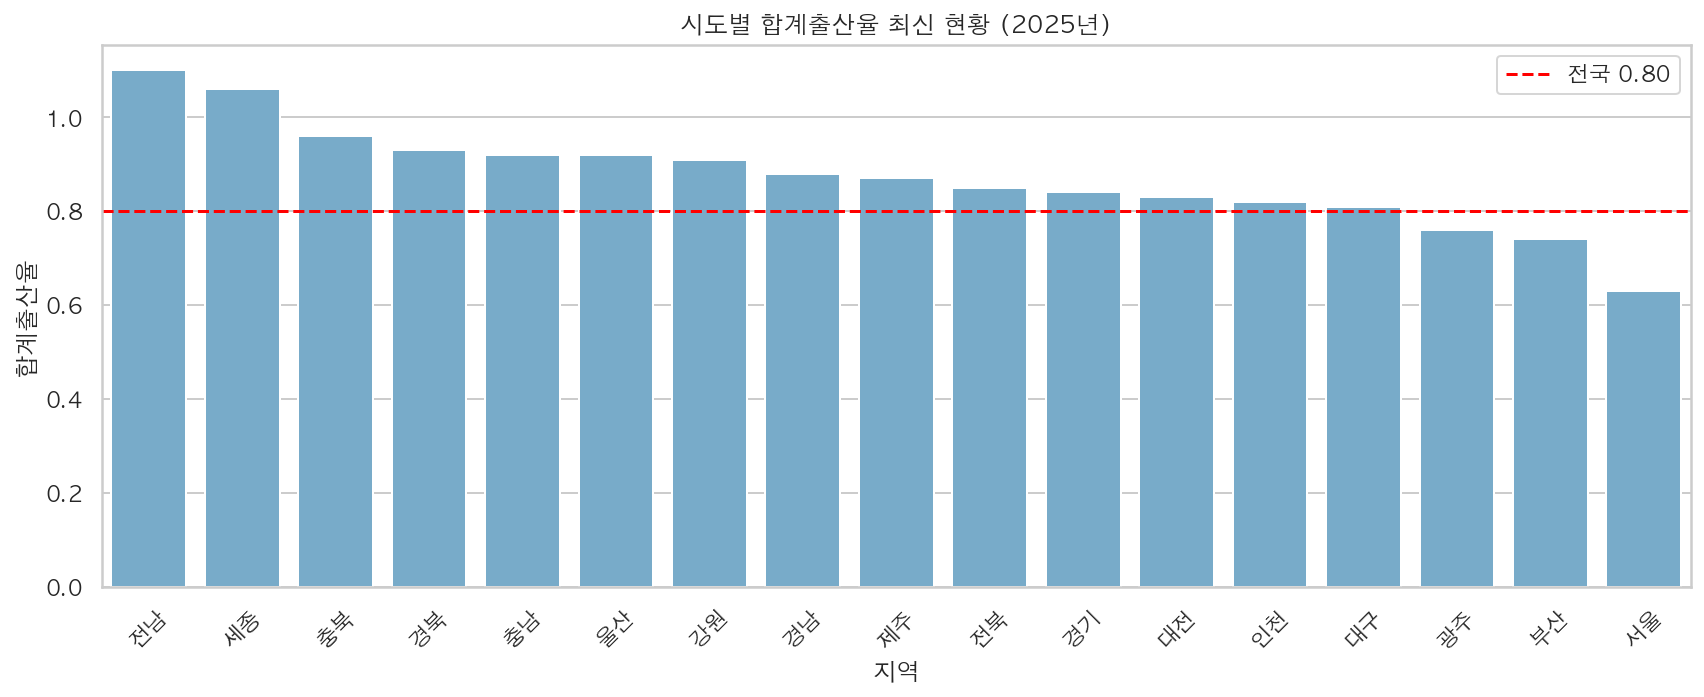

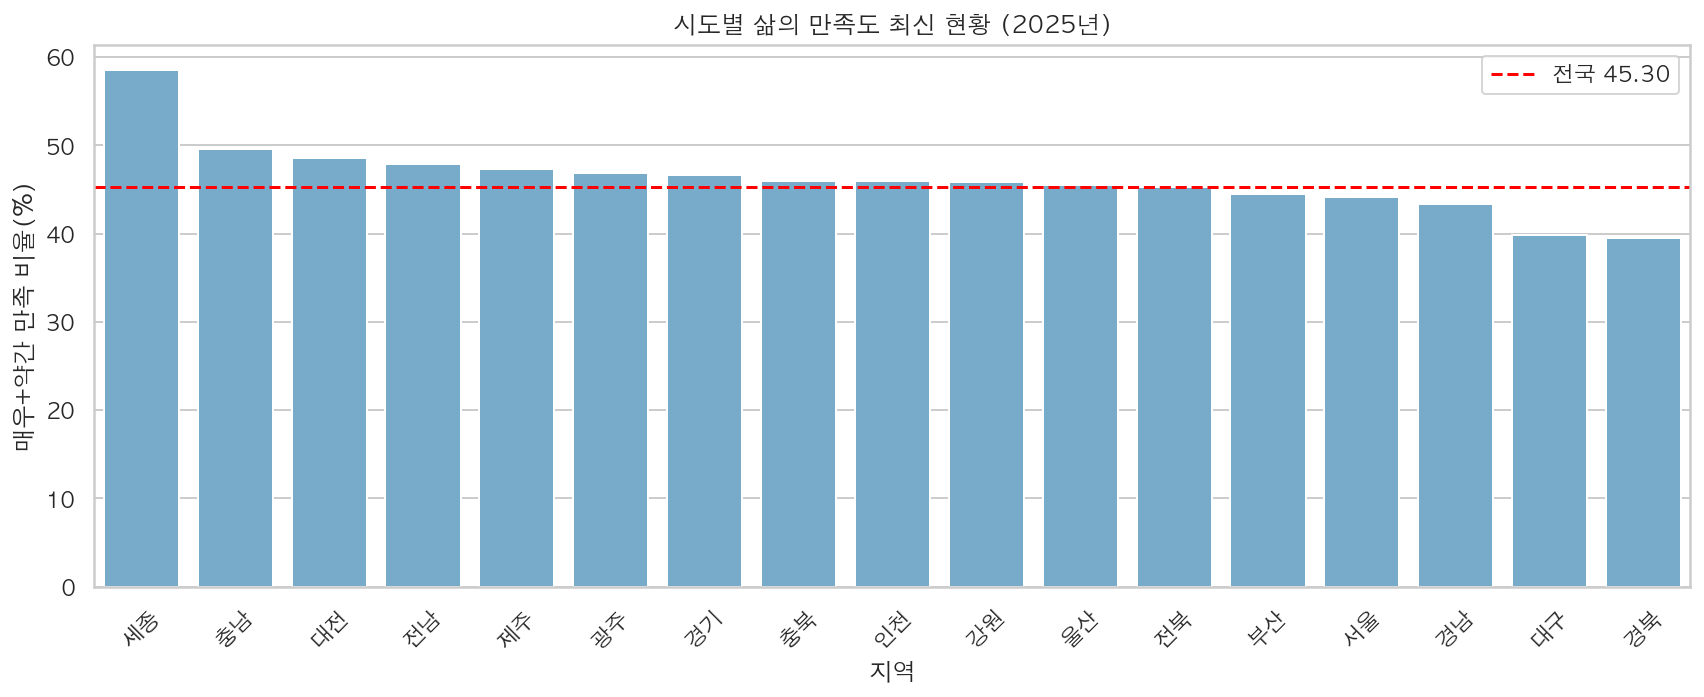

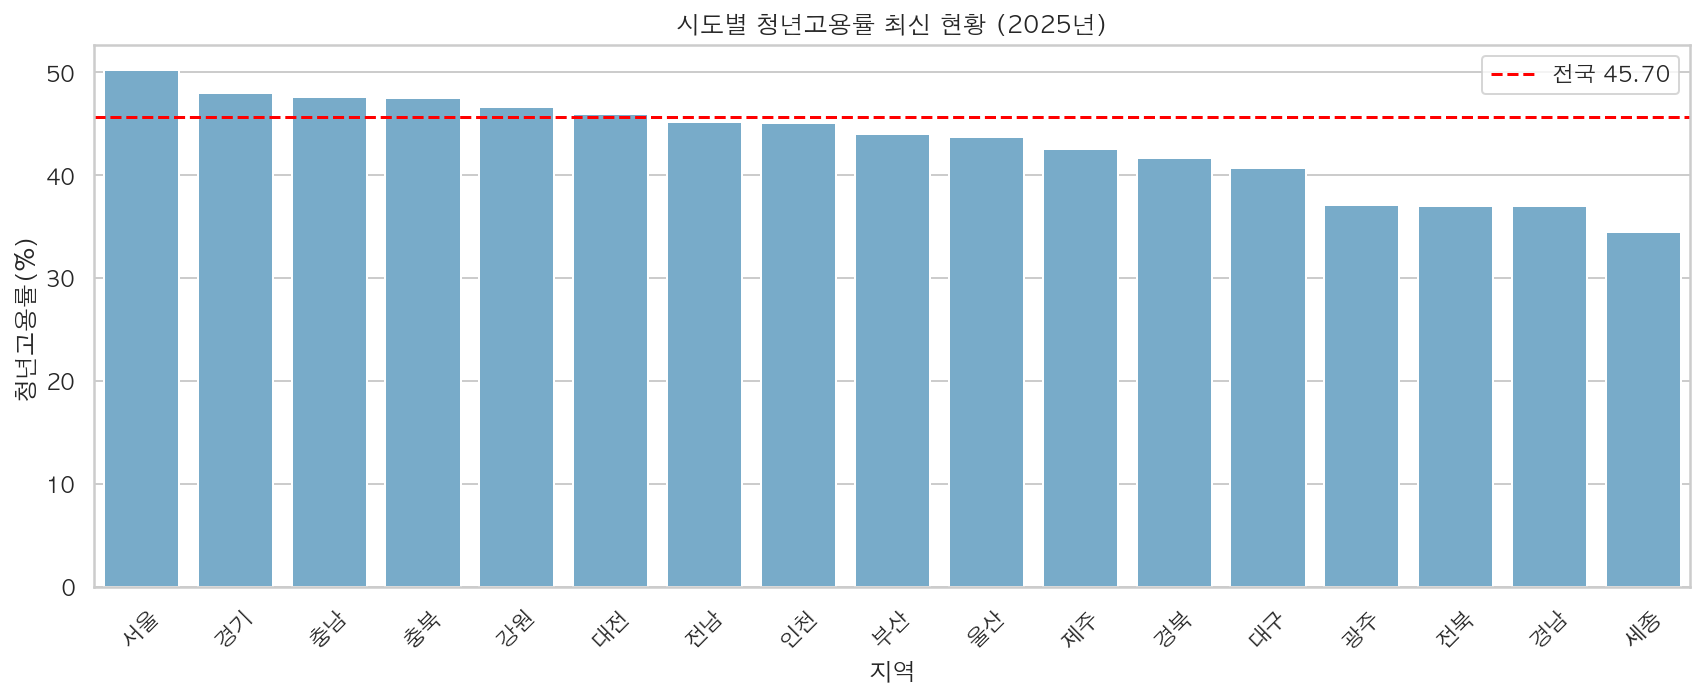

In [14]:
def latest_year_for(var):
    non_null = panel.dropna(subset=[var])
    return int(non_null["연도"].max())


def plot_latest_bar(var, title, ylabel):
    year = latest_year_for(var)
    df_year = panel[(panel["연도"] == year) & (panel["지역"] != "전국")][["지역", var]].dropna()
    df_year = df_year.sort_values(var, ascending=False)
    national = panel[(panel["연도"] == year) & (panel["지역"] == "전국")][var]

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_year, x="지역", y=var, color="#6BAED6")
    if not national.empty and pd.notna(national.iloc[0]):
        plt.axhline(national.iloc[0], color="red", linestyle="--", label=f"전국 {national.iloc[0]:.2f}")
        plt.legend()
    plt.title(f"{title} ({year}년)")
    plt.xlabel("지역")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_latest_bar("출산율", "시도별 합계출산율 최신 현황", "합계출산율")
plot_latest_bar("삶의만족도", "시도별 삶의 만족도 최신 현황", "매우+약간 만족 비율(%)")
plot_latest_bar("청년고용률", "시도별 청년고용률 최신 현황", "청년고용률(%)")

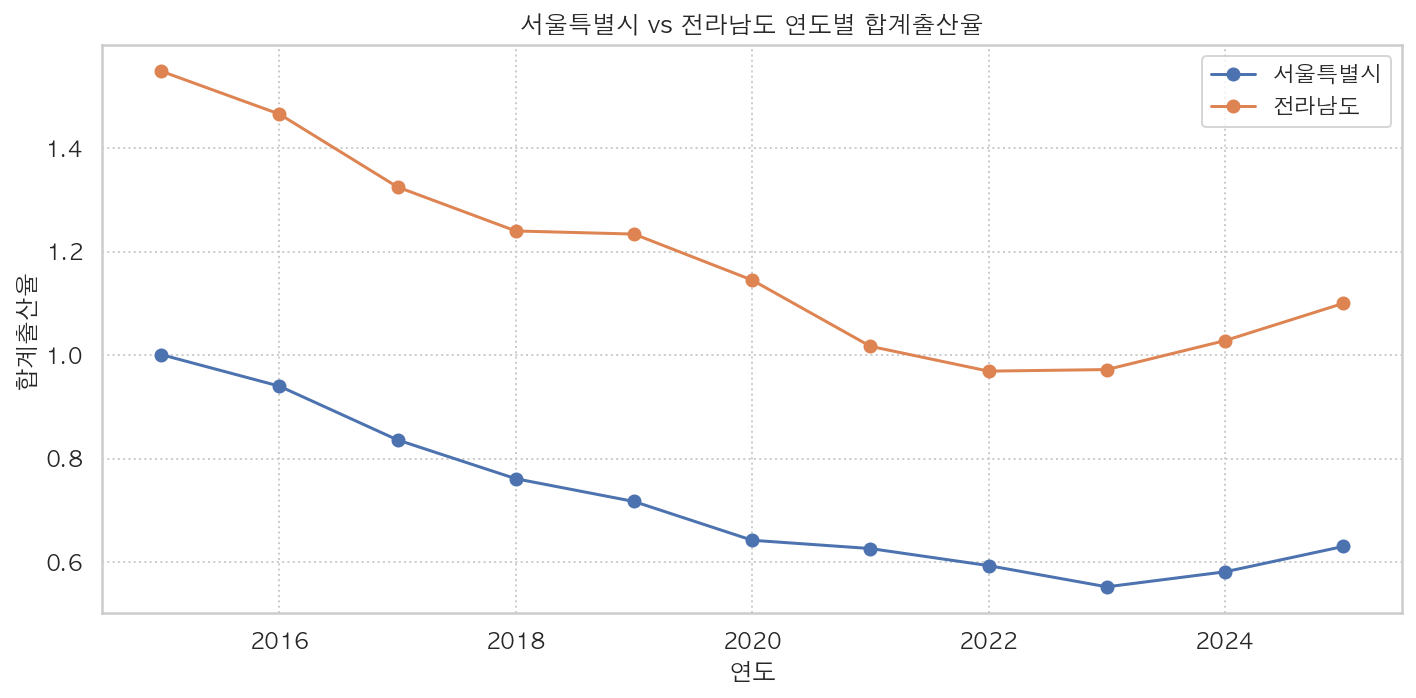

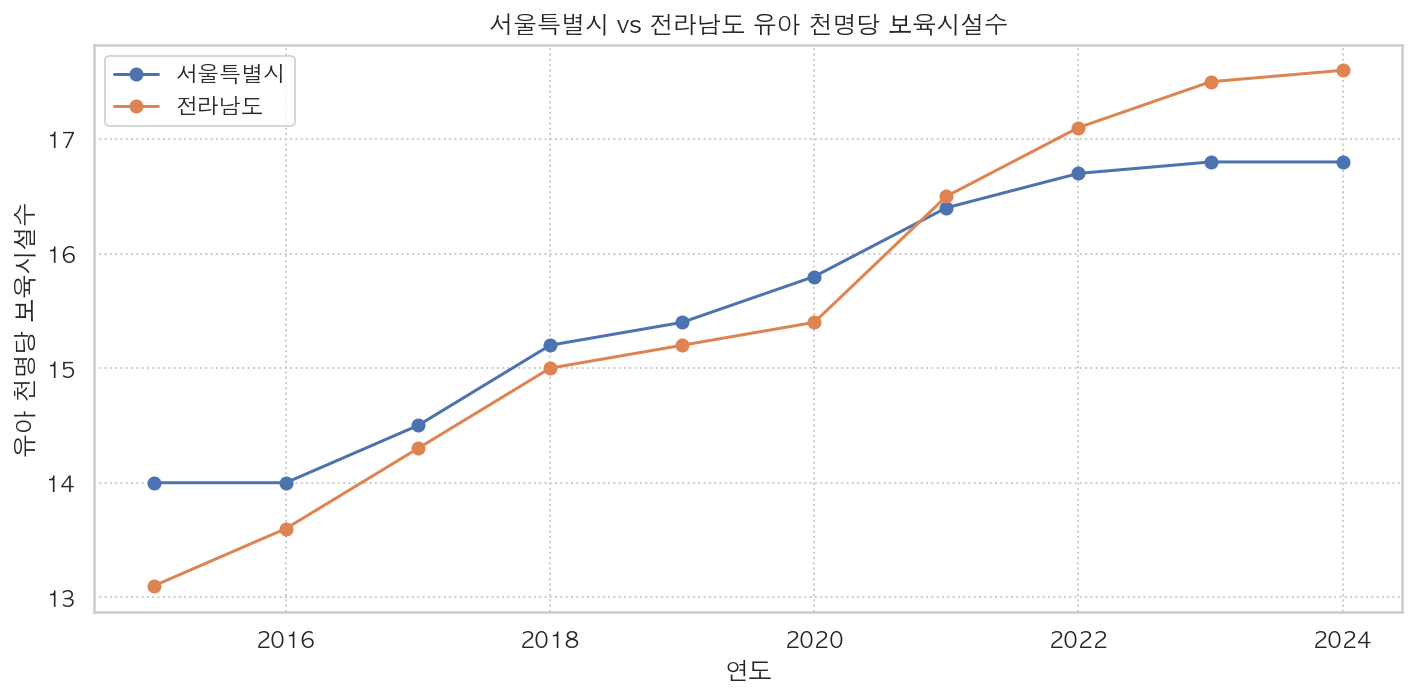

In [15]:
def compare_region_trend(var, regions=("서울", "전남"), title=None, ylabel=None):
    plt.figure(figsize=(10, 5))
    for region in regions:
        temp = panel[(panel["지역"] == region)][["연도", var]].dropna().sort_values("연도")
        plt.plot(temp["연도"], temp[var], marker="o", label=REGION_DISPLAY.get(region, region))
    plt.title(title or f"{var} 지역별 추세")
    plt.xlabel("연도")
    plt.ylabel(ylabel or var)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()


compare_region_trend("출산율", title="서울특별시 vs 전라남도 연도별 합계출산율", ylabel="합계출산율")
compare_region_trend("보육시설", title="서울특별시 vs 전라남도 유아 천명당 보육시설수", ylabel="유아 천명당 보육시설수")

## 06 강의자료 기준 분석: complete-case

먼저 교수님 방식에 가깝게 결측이 있는 행을 제거하고 분석합니다. 이 결과를 메인 결과로 둡니다.

In [16]:
min_obs = max(8, len(FACTOR_VARS) + 2)
complete_case_counts = (
    panel.groupby("연도")[MODEL_VARS]
    .apply(lambda df: df.dropna().shape[0])
    .rename("complete_case_지역수")
    .reset_index()
)

candidate_years = complete_case_counts[complete_case_counts["complete_case_지역수"] >= min_obs]
if candidate_years.empty:
    candidate_years = complete_case_counts[complete_case_counts["complete_case_지역수"] > 0]

ANALYSIS_YEAR = int(candidate_years["연도"].max())
print("통합 분석 기준 연도:", ANALYSIS_YEAR)
display(complete_case_counts)

complete_case_df = panel[panel["연도"] == ANALYSIS_YEAR][["지역"] + MODEL_VARS].dropna()
print("complete-case 표본 수:", complete_case_df.shape[0])
display(complete_case_df)

통합 분석 기준 연도: 2023
complete-case 표본 수: 18


      연도  complete_case_지역수
0   2015                  0
1   2016                  0
2   2017                 17
3   2018                  0
4   2019                 18
5   2020                  0
6   2021                 18
7   2022                  0
8   2023                 18
9   2024                  0
10  2025                  0

     지역    출산율  보육시설  주거안정률  삶의만족도  주관적소득부족  맞벌이가구비율    물가지수   범죄율  청년고용률    어린이집충족률     개인소득
144  강원  0.893  17.9   69.3   47.1     54.6     52.1  112.99  28.3   44.7  70.504923  24041.0
145  경기  0.766  17.8   59.2   41.3     56.0     47.0  111.55  27.7   50.3  75.760241  26488.0
146  경남  0.799  19.0   70.1   44.4     54.4     51.3  111.76  27.8   41.8  67.288376  23671.0
147  경북  0.860  17.5   73.6   38.1     55.5     52.6  112.39  26.6   39.2  66.289676  23677.0
148  광주  0.706  17.9   64.4   43.0     53.7     48.9  111.76  29.6   39.2  66.271112  26142.0
149  대구  0.702  14.8   62.2   37.6     59.9     43.2  111.79  28.1   44.7  69.354610  24603.0
150  대전  0.787  18.7   55.4   49.0     52.5     49.1  111.24  30.0   44.8  71.504016  27418.0
151  부산  0.664  15.2   62.9   40.5     56.1     42.3  111.33  32.3   43.2  71.106609  24853.0
152  서울  0.552  16.8   46.5   41.9     54.1     43.6  110.88  29.5   51.4  73.492293  30382.0
153  세종  0.971  14.5   60.2   53.3     50.6     54.8  111.46

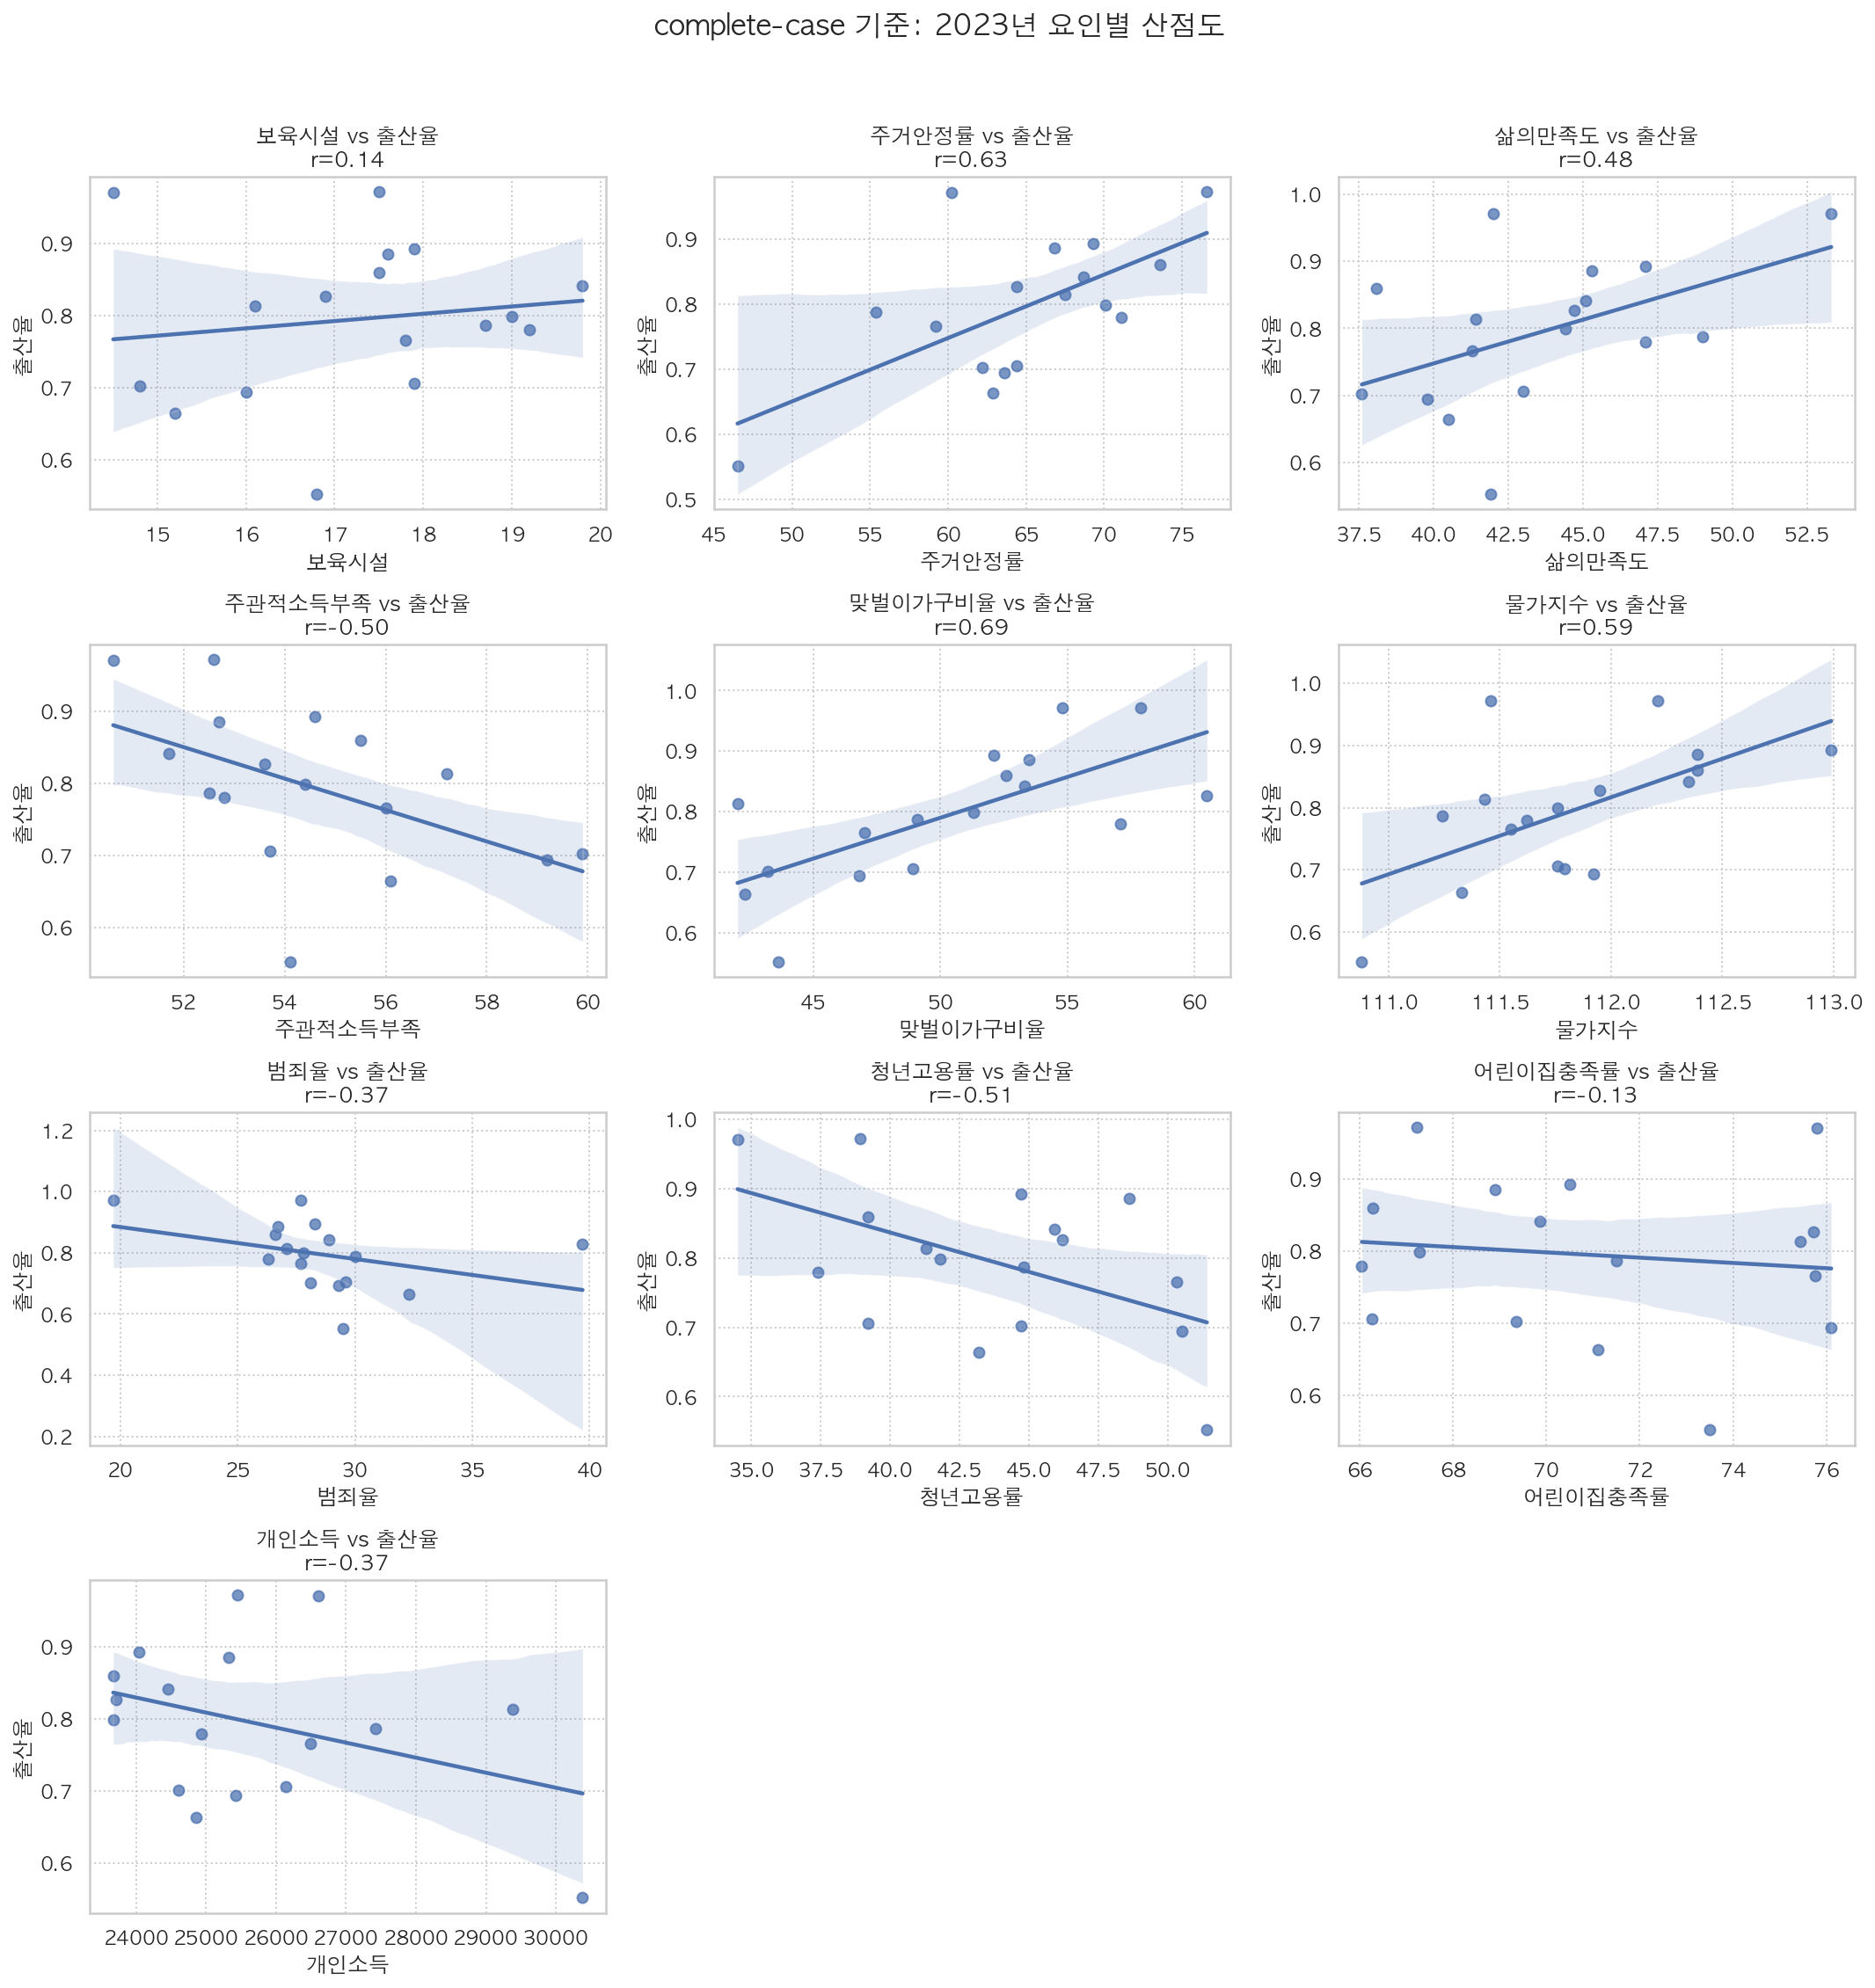

In [17]:
def plot_scatter_grid(panel_data, features, year, title_prefix):
    n_cols = 3
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = np.array(axes).reshape(-1)

    for idx, feature in enumerate(features):
        ax = axes[idx]
        temp = panel_data[
            (panel_data["연도"] == year) & (panel_data["지역"] != "전국")
        ][["출산율", feature]].dropna()
        sns.regplot(data=temp, x=feature, y="출산율", ax=ax, scatter_kws={"alpha": 0.75})
        corr = temp["출산율"].corr(temp[feature]) if temp.shape[0] >= 3 else np.nan
        ax.set_title(f"{feature} vs 출산율\nr={corr:.2f}")
        ax.grid(True, linestyle=":")

    for idx in range(len(features), len(axes)):
        axes[idx].axis("off")

    plt.suptitle(f"{title_prefix}: {year}년 요인별 산점도", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


plot_scatter_grid(panel, FACTOR_VARS, ANALYSIS_YEAR, "complete-case 기준")

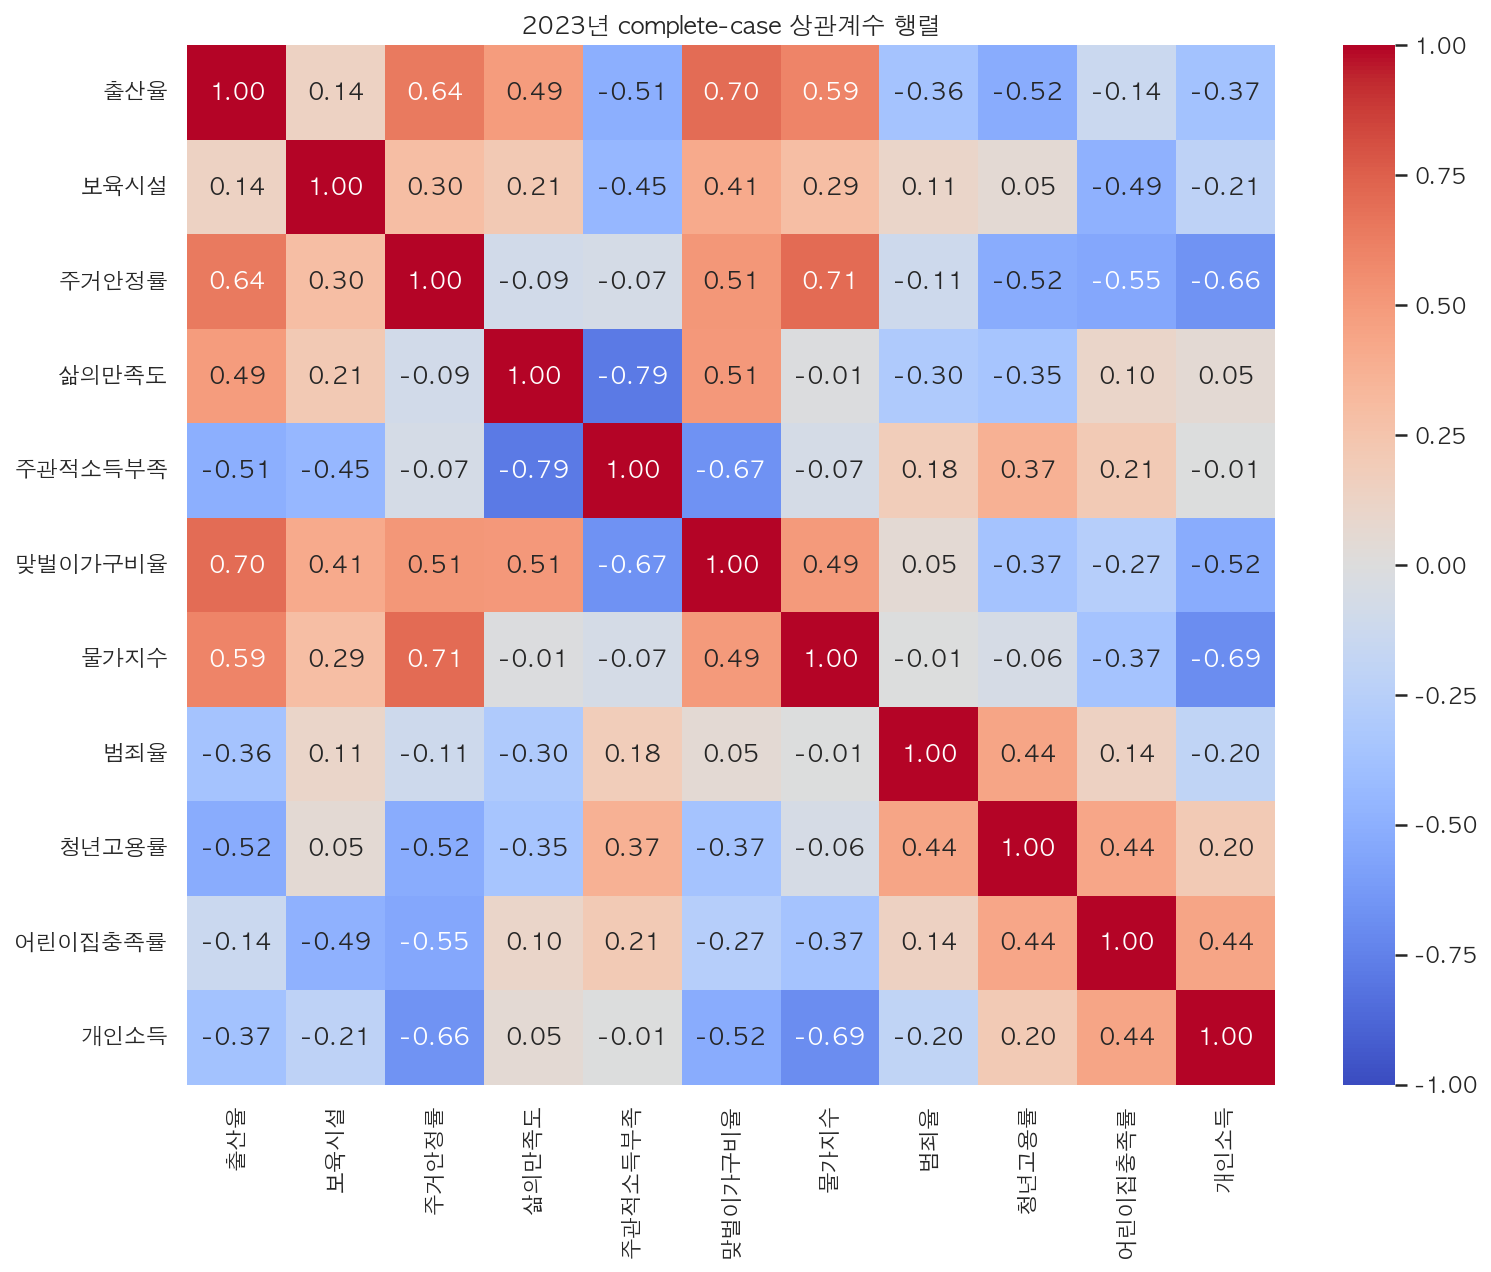

In [18]:
def plot_corr_heatmap(df, variables, title):
    corr = df[variables].corr()
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return corr


complete_corr = plot_corr_heatmap(
    complete_case_df,
    MODEL_VARS,
    f"{ANALYSIS_YEAR}년 complete-case 상관계수 행렬",
)

[complete-case] 분석 연도: 2023
[complete-case] 표본 수: 17
[complete-case] 변수 수: 10
[complete-case] 선택된 주성분 개수: 4
[complete-case] R²: 0.755


        변수  cosine_similarity  rank
4  맞벌이가구비율           0.993466     1
0     보육시설           0.874968     2
2    삶의만족도           0.653473     3
1    주거안정률           0.532837     4
5     물가지수           0.440644     5
9     개인소득          -0.332878     6
8  어린이집충족률          -0.525435     7
6      범죄율          -0.635571     8
3  주관적소득부족          -0.791568     9
7    청년고용률          -0.971905    10

        변수  pcr_coef
0  맞벌이가구비율  0.028346
1    삶의만족도  0.024137
2     물가지수  0.018976
3    주거안정률  0.018087
4  어린이집충족률  0.012453
5      범죄율 -0.011537
6  주관적소득부족 -0.013089
7     보육시설 -0.020010
8     개인소득 -0.020419
9    청년고용률 -0.024253

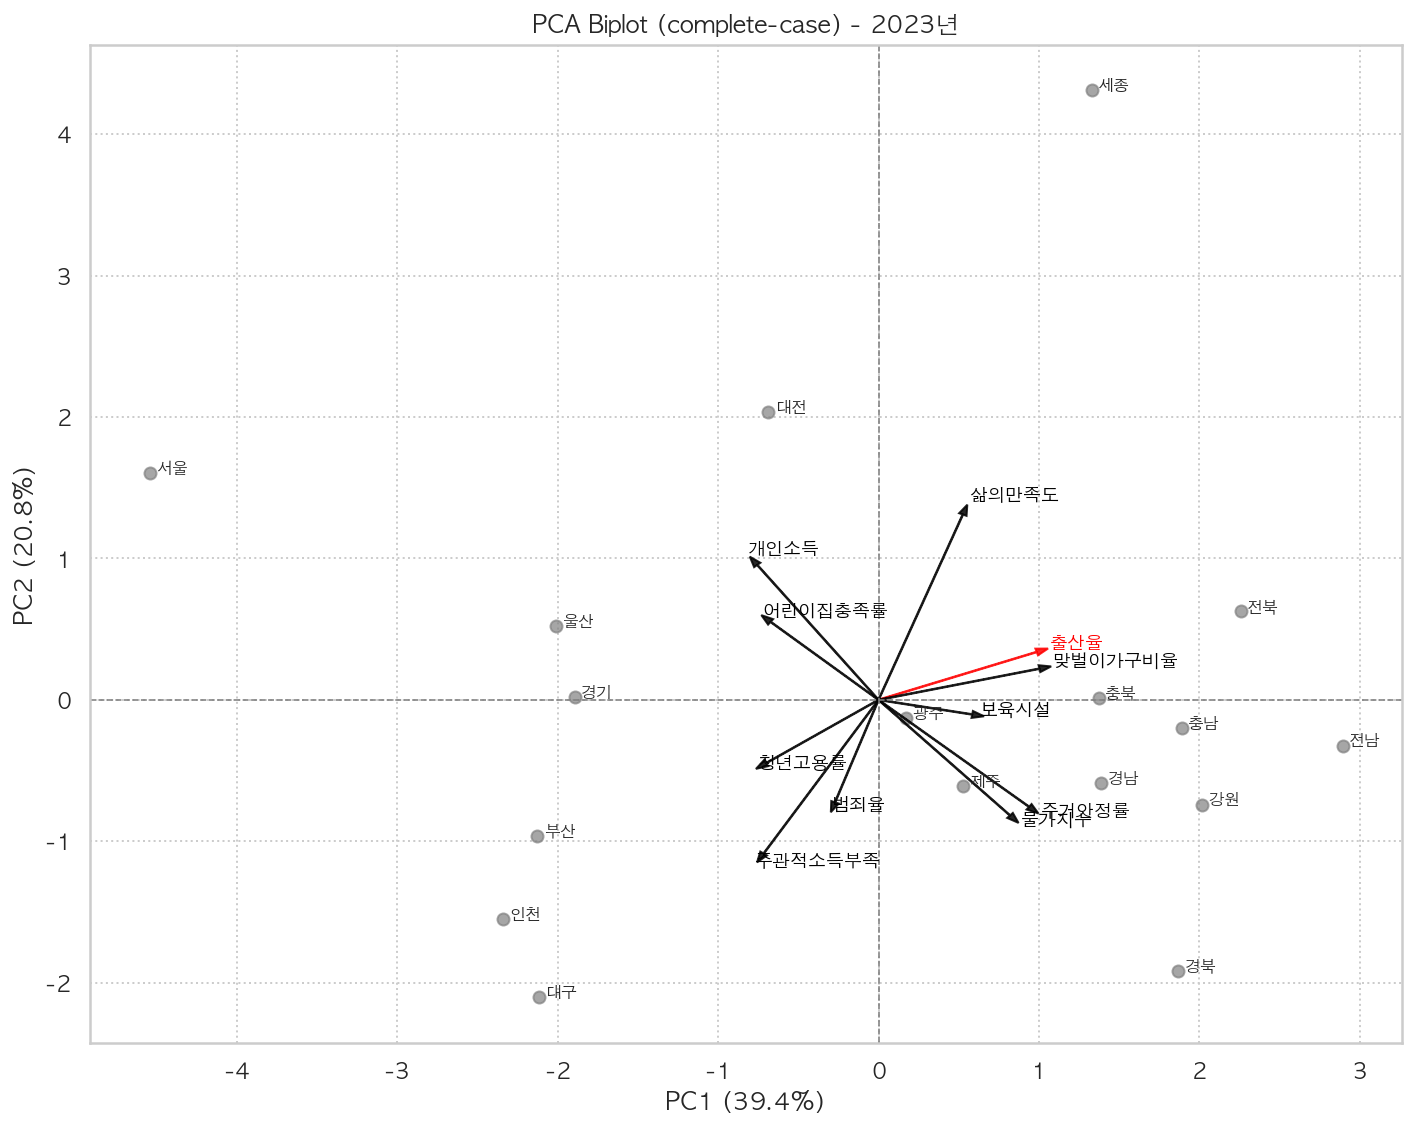

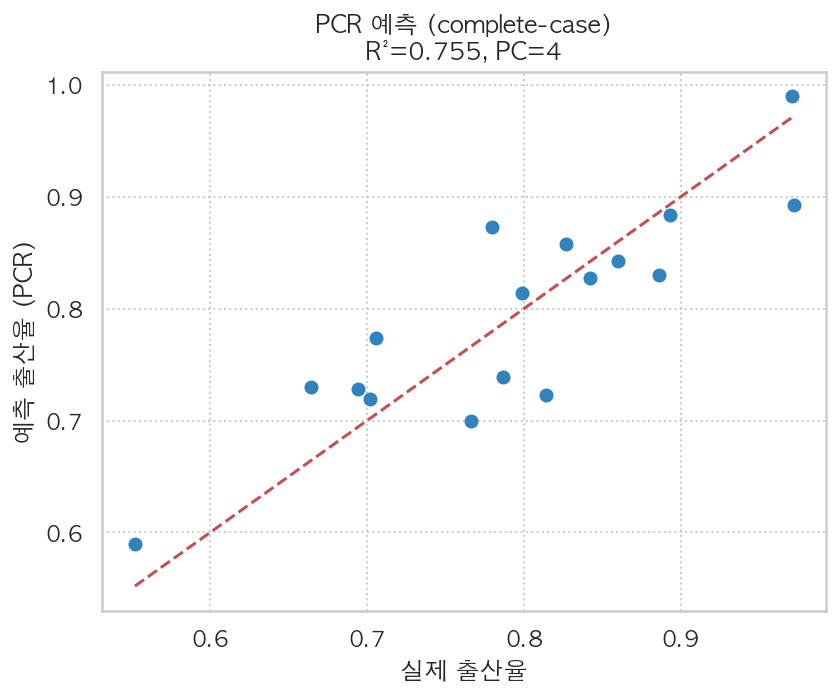

In [19]:
def run_pca_pcr(panel_data, features, year, label):
    df_year = panel_data[panel_data["연도"] == year][["지역", "출산율"] + features].dropna().copy()
    df_year = df_year[df_year["지역"] != "전국"].reset_index(drop=True)

    print(f"[{label}] 분석 연도:", year)
    print(f"[{label}] 표본 수:", df_year.shape[0])
    print(f"[{label}] 변수 수:", len(features))

    if df_year.shape[0] < 4:
        raise ValueError(f"{label}: PCA/PCR을 수행하기에 표본 수가 너무 적습니다.")

    pca_variables = ["출산율"] + features
    scaler_all = StandardScaler()
    all_scaled = scaler_all.fit_transform(df_year[pca_variables])

    pca_2 = PCA(n_components=2)
    coords = pca_2.fit_transform(all_scaled)
    loadings = pd.DataFrame(pca_2.components_.T, index=pca_variables, columns=["PC1", "PC2"])

    plt.figure(figsize=(10, 8))
    for i, region in enumerate(df_year["지역"]):
        plt.scatter(coords[i, 0], coords[i, 1], color="gray", alpha=0.7)
        plt.text(coords[i, 0] + 0.04, coords[i, 1], region, fontsize=8)

    scale = 2.5
    for variable in pca_variables:
        color = "red" if variable == "출산율" else "black"
        plt.arrow(
            0,
            0,
            loadings.loc[variable, "PC1"] * scale,
            loadings.loc[variable, "PC2"] * scale,
            color=color,
            width=0.004,
            head_width=0.05,
            alpha=0.85,
        )
        plt.text(
            loadings.loc[variable, "PC1"] * scale * 1.08,
            loadings.loc[variable, "PC2"] * scale * 1.08,
            variable,
            color=color,
            fontsize=9,
        )

    plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0] * 100:.1f}%)")
    plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1] * 100:.1f}%)")
    plt.title(f"PCA Biplot ({label}) - {year}년")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    target_vec = loadings.loc["출산율", ["PC1", "PC2"]].values.reshape(1, -1)
    cosine_rows = []
    for feature in features:
        feature_vec = loadings.loc[feature, ["PC1", "PC2"]].values.reshape(1, -1)
        cosine_rows.append(
            {
                "변수": feature,
                "cosine_similarity": cosine_similarity(target_vec, feature_vec)[0][0],
            }
        )
    cosine_df = pd.DataFrame(cosine_rows).sort_values("cosine_similarity", ascending=False)
    cosine_df["rank"] = range(1, len(cosine_df) + 1)

    X = df_year[features].astype(float)
    y = df_year["출산율"].astype(float)

    scaler_x = StandardScaler()
    X_scaled = scaler_x.fit_transform(X)

    pca_full = PCA()
    X_pca = pca_full.fit_transform(X_scaled)
    explained_ratio = np.cumsum(pca_full.explained_variance_ratio_)
    n_components = int(np.argmax(explained_ratio >= 0.8) + 1)

    model = LinearRegression()
    X_pca_reduced = X_pca[:, :n_components]
    model.fit(X_pca_reduced, y)
    y_pred = model.predict(X_pca_reduced)
    r_squared = model.score(X_pca_reduced, y)

    plt.figure(figsize=(6, 5))
    plt.scatter(y, y_pred, color="#3182BD")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
    plt.xlabel("실제 출산율")
    plt.ylabel("예측 출산율 (PCR)")
    plt.title(f"PCR 예측 ({label})\nR²={r_squared:.3f}, PC={n_components}")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    V = pca_full.components_[:n_components, :].T
    beta_orig = V @ model.coef_
    coef_df = (
        pd.DataFrame({"변수": features, "pcr_coef": beta_orig})
        .sort_values("pcr_coef", ascending=False)
        .reset_index(drop=True)
    )

    print(f"[{label}] 선택된 주성분 개수:", n_components)
    print(f"[{label}] R²:", round(r_squared, 3))
    display(cosine_df)
    display(coef_df)

    return {
        "label": label,
        "year": year,
        "sample_size": df_year.shape[0],
        "loadings": loadings,
        "cosine": cosine_df,
        "coef": coef_df,
        "r_squared": r_squared,
        "n_components": n_components,
    }


complete_result = run_pca_pcr(panel, FACTOR_VARS, ANALYSIS_YEAR, "complete-case")

## 07 보간 적용 분석

이 단계는 메인 결론이 아니라 민감도 분석입니다. `week10`의 결측 대체 흐름을 반영해 다음 순서로 처리합니다.

1. 지역별 시계열 내부 결측: 선형 보간
2. 양끝 결측: 같은 변수·같은 연도의 시도 평균
3. 그래도 남는 결측: 해당 변수 전체 평균

In [20]:
def make_imputed_panel(panel_data, variables):
    years = sorted(panel_data["연도"].dropna().astype(int).unique())
    regions = [region for region in REGION_ORDER if region in panel_data["지역"].dropna().unique()]

    grid = pd.MultiIndex.from_product([regions, years], names=["지역", "연도"]).to_frame(index=False)
    base = grid.merge(panel_data, on=["지역", "연도"], how="left")

    imputation_rows = []
    for var in variables:
        before = base[var].copy()
        base[var] = base.groupby("지역")[var].transform(
            lambda series: series.interpolate(method="linear", limit_area="inside")
        )
        base[var] = base.groupby("연도")[var].transform(lambda series: series.fillna(series.mean()))
        base[var] = base[var].fillna(base[var].mean())
        flag_col = f"{var}_is_imputed"
        base[flag_col] = before.isna() & base[var].notna()
        imputation_rows.append(
            {
                "변수": var,
                "원래결측수": int(before.isna().sum()),
                "보간후결측수": int(base[var].isna().sum()),
                "보간값수": int(base[flag_col].sum()),
            }
        )

    return base, pd.DataFrame(imputation_rows)


imputed_panel, imputation_summary = make_imputed_panel(panel, MODEL_VARS)
display(imputation_summary)

original_year_quality = (
    panel.groupby("연도")[MODEL_VARS]
    .apply(lambda df: (df.notna().sum() >= 12).mean())
    .rename("원자료_변수커버리지")
    .reset_index()
)
display(original_year_quality)

imputed_year_candidates = original_year_quality[
    original_year_quality["원자료_변수커버리지"] >= 0.8
]
if imputed_year_candidates.empty:
    IMPUTED_ANALYSIS_YEAR = ANALYSIS_YEAR
else:
    IMPUTED_ANALYSIS_YEAR = int(imputed_year_candidates["연도"].max())

print("complete-case 분석 연도:", ANALYSIS_YEAR)
print("보간 적용 분석 연도:", IMPUTED_ANALYSIS_YEAR)

imputed_case_df = imputed_panel[imputed_panel["연도"] == IMPUTED_ANALYSIS_YEAR][["지역"] + MODEL_VARS]
print("보간 적용 표본 수:", imputed_case_df.dropna().shape[0])
display(imputed_case_df.head())

complete-case 분석 연도: 2023
보간 적용 분석 연도: 2024
보간 적용 표본 수: 18


         변수  원래결측수  보간후결측수  보간값수
0       출산율      0       0     0
1      보육시설     18       0    18
2     주거안정률     37       0    37
3     삶의만족도      0       0     0
4   주관적소득부족     90       0    90
5   맞벌이가구비율     20       0    20
6      물가지수      0       0     0
7       범죄율     22       0    22
8     청년고용률      2       0     2
9   어린이집충족률     18       0    18
10     개인소득     18       0    18

      연도  원자료_변수커버리지
0   2015    0.909091
1   2016    0.909091
2   2017    1.000000
3   2018    0.909091
4   2019    1.000000
5   2020    0.909091
6   2021    1.000000
7   2022    0.909091
8   2023    1.000000
9   2024    0.909091
10  2025    0.454545

    지역    출산율  보육시설  주거안정률  삶의만족도  주관적소득부족  맞벌이가구비율    물가지수   범죄율  청년고용률    어린이집충족률     개인소득
9   전국  0.748  17.3   62.0   40.1    53.40     48.0  114.18  30.9   46.6  70.241932  27825.0
20  서울  0.581  16.8   46.6   46.3    53.50     43.7  113.50  32.4   50.9  70.743679  32224.0
31  부산  0.683  15.2   63.9   37.5    53.35     43.3  114.12  34.4   46.6  70.338945  26157.0
42  대구  0.754  15.0   63.5   36.1    56.25     42.3  114.20  29.9   39.5  67.059652  25784.0
53  인천  0.762  16.0   64.7   28.0    55.30     47.2  114.79  30.6   47.4  74.982754  26869.0

[imputed] 분석 연도: 2024
[imputed] 표본 수: 17
[imputed] 변수 수: 10
[imputed] 선택된 주성분 개수: 4
[imputed] R²: 0.483


        변수  cosine_similarity  rank
1    주거안정률           0.998132     1
5     물가지수           0.949678     2
4  맞벌이가구비율           0.562339     3
0     보육시설           0.056017     4
2    삶의만족도          -0.328720     5
3  주관적소득부족          -0.377118     6
8  어린이집충족률          -0.625972     7
6      범죄율          -0.753924     8
7    청년고용률          -0.931053     9
9     개인소득          -0.996968    10

        변수  pcr_coef
0    주거안정률  0.018976
1     물가지수  0.017151
2  맞벌이가구비율  0.004313
3     보육시설  0.003802
4    삶의만족도 -0.001242
5     개인소득 -0.004837
6  주관적소득부족 -0.010679
7  어린이집충족률 -0.016712
8    청년고용률 -0.017192
9      범죄율 -0.026197

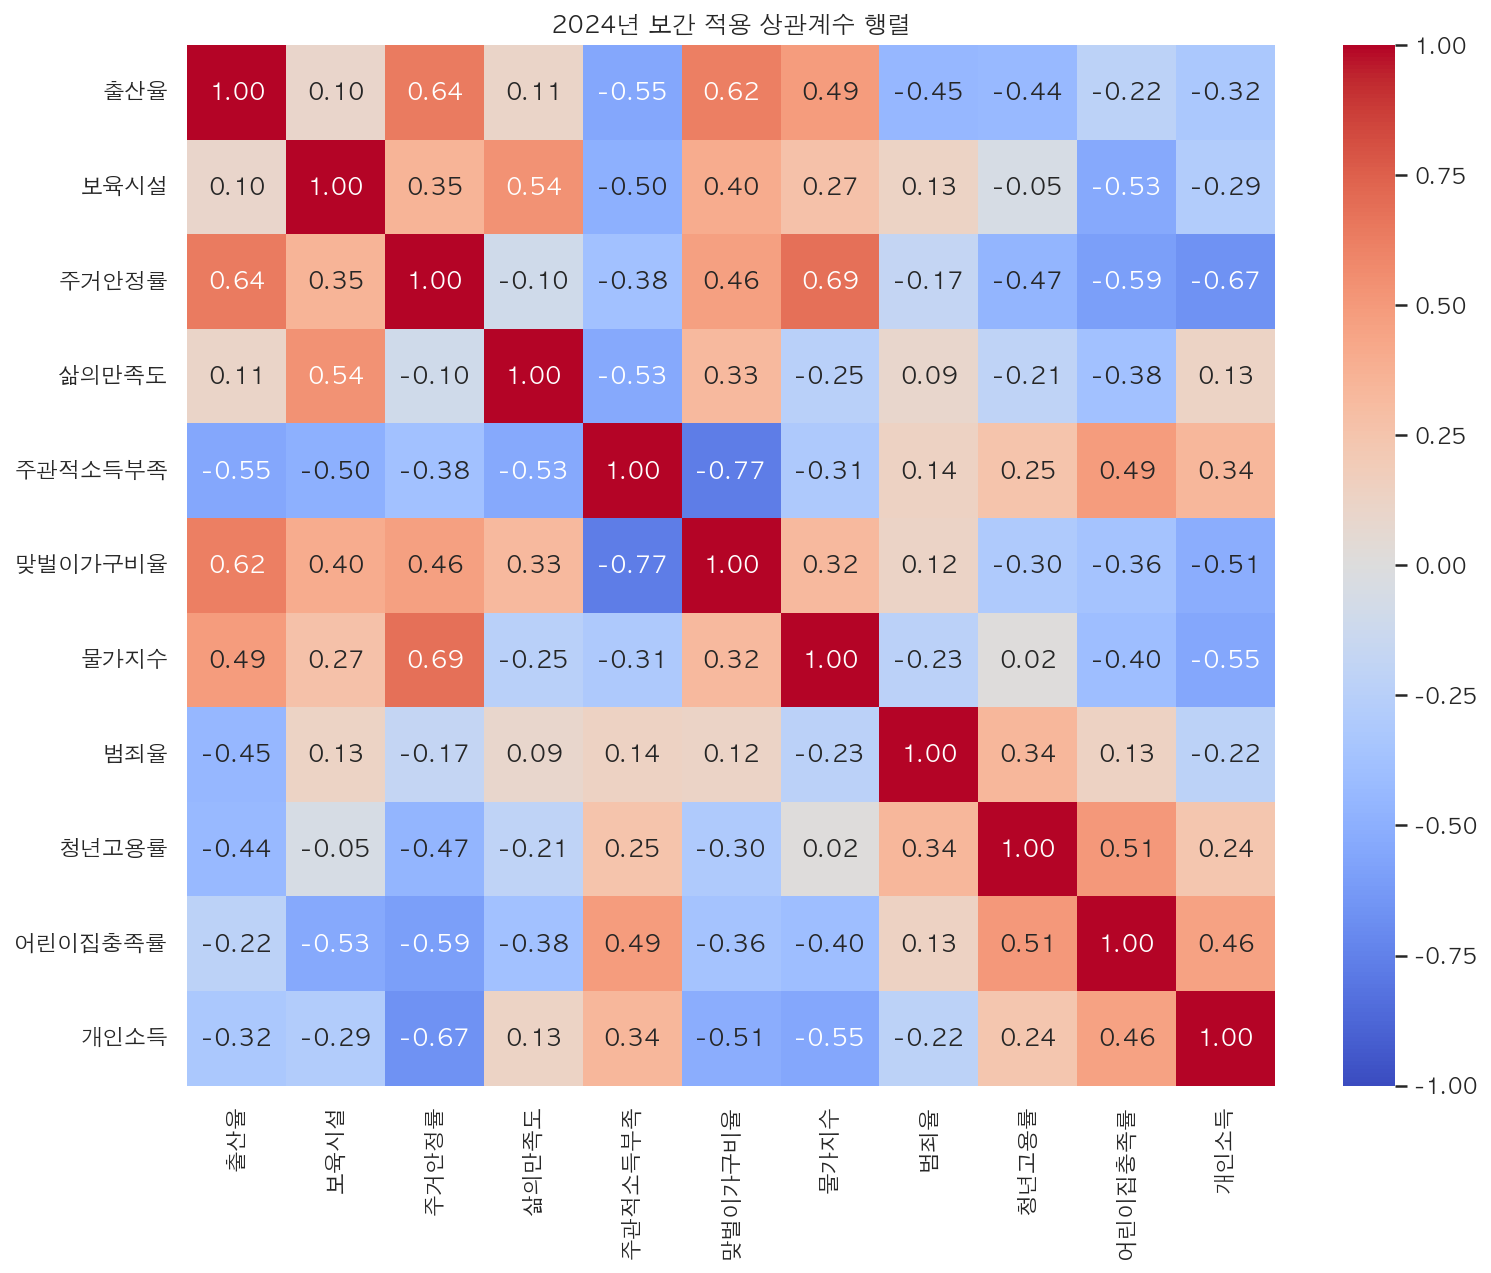

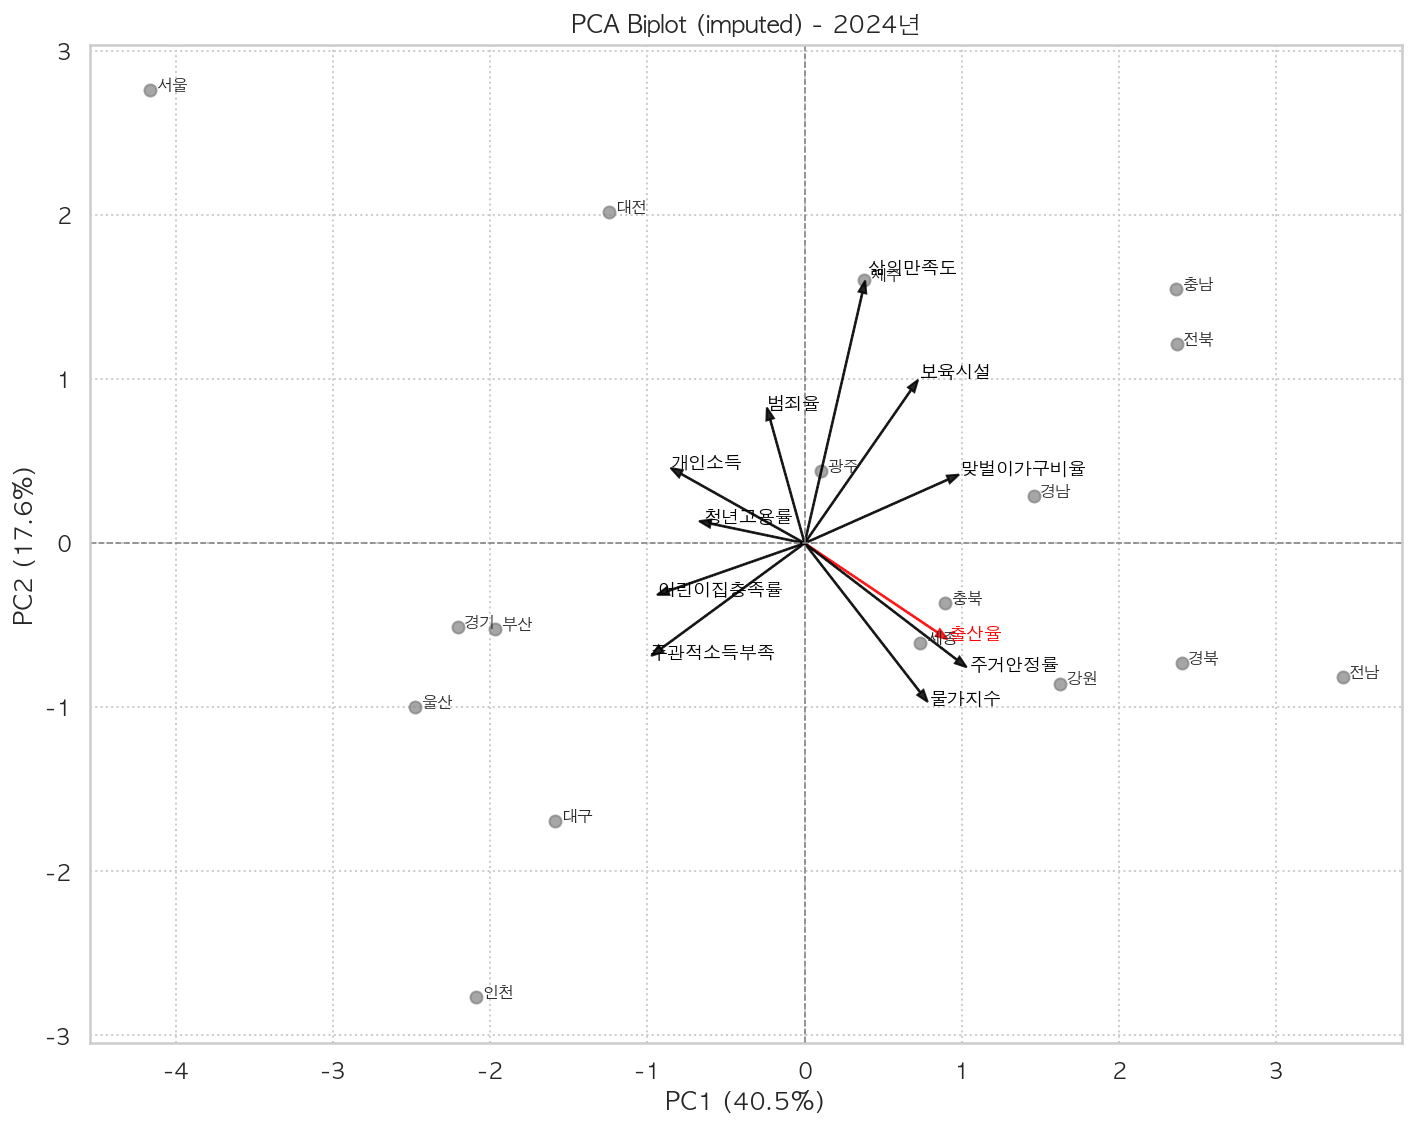

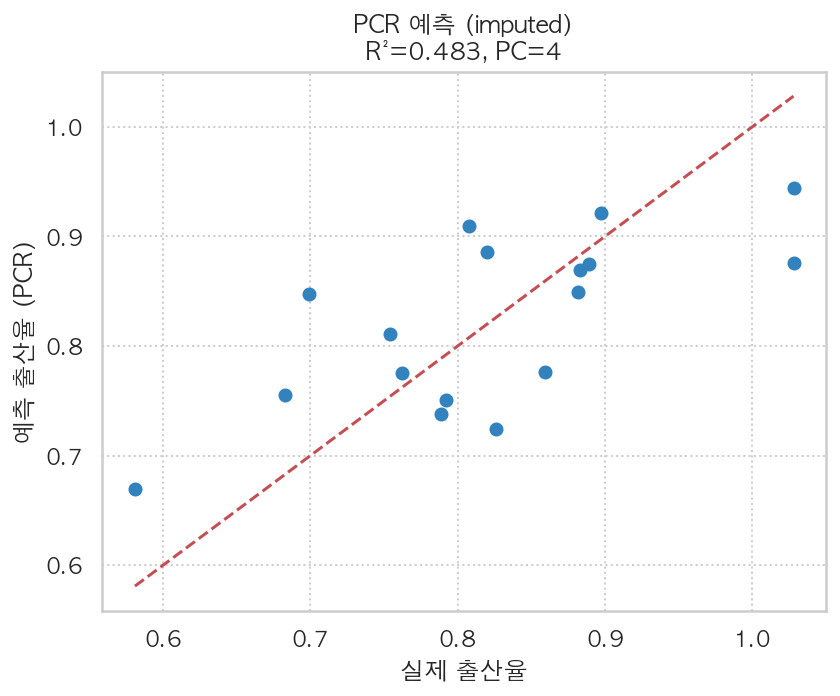

In [21]:
imputed_corr = plot_corr_heatmap(
    imputed_case_df.dropna(),
    MODEL_VARS,
    f"{IMPUTED_ANALYSIS_YEAR}년 보간 적용 상관계수 행렬",
)

imputed_result = run_pca_pcr(imputed_panel, FACTOR_VARS, IMPUTED_ANALYSIS_YEAR, "imputed")

## 08 complete-case와 보간 결과 비교

발표에서는 complete-case 결과를 메인으로 설명하고, 보간 결과는 “결과가 크게 바뀌는지 확인한 민감도 분석”으로 간단히 제시합니다.
보간 분석은 원자료 커버리지가 충분한 최신 연도를 자동 선택하므로 complete-case 기준 연도와 다를 수 있습니다.

In [22]:
complete_cosine = complete_result["cosine"][["변수", "cosine_similarity", "rank"]].rename(
    columns={
        "cosine_similarity": "complete_case_cosine",
        "rank": "complete_case_rank",
    }
)
imputed_cosine = imputed_result["cosine"][["변수", "cosine_similarity", "rank"]].rename(
    columns={
        "cosine_similarity": "imputed_cosine",
        "rank": "imputed_rank",
    }
)

complete_coef = complete_result["coef"].rename(columns={"pcr_coef": "complete_case_pcr_coef"})
imputed_coef = imputed_result["coef"].rename(columns={"pcr_coef": "imputed_pcr_coef"})

comparison_df = (
    complete_cosine
    .merge(imputed_cosine, on="변수", how="outer")
    .merge(complete_coef, on="변수", how="outer")
    .merge(imputed_coef, on="변수", how="outer")
)
comparison_df["rank_change"] = comparison_df["imputed_rank"] - comparison_df["complete_case_rank"]
comparison_df = comparison_df.sort_values("complete_case_rank").reset_index(drop=True)

display(comparison_df)

top_complete = comparison_df.sort_values("complete_case_rank").head(3)["변수"].tolist()
top_imputed = comparison_df.sort_values("imputed_rank").head(3)["변수"].tolist()

print(f"complete-case 기준 연도: {ANALYSIS_YEAR}")
print(f"보간 적용 기준 연도: {IMPUTED_ANALYSIS_YEAR}")
print("complete-case 기준 상위 3개 요인:", top_complete)
print("보간 적용 기준 상위 3개 요인:", top_imputed)
print("complete-case R²:", round(complete_result["r_squared"], 3))
print("imputed R²:", round(imputed_result["r_squared"], 3))

complete-case 기준 연도: 2023
보간 적용 기준 연도: 2024
complete-case 기준 상위 3개 요인: ['맞벌이가구비율', '보육시설', '삶의만족도']
보간 적용 기준 상위 3개 요인: ['주거안정률', '물가지수', '맞벌이가구비율']
complete-case R²: 0.755
imputed R²: 0.483


        변수  complete_case_cosine  complete_case_rank  imputed_cosine  imputed_rank  complete_case_pcr_coef  imputed_pcr_coef  rank_change
0  맞벌이가구비율              0.993466                   1        0.562339             3                0.028346          0.004313            2
1     보육시설              0.874968                   2        0.056017             4               -0.020010          0.003802            2
2    삶의만족도              0.653473                   3       -0.328720             5                0.024137         -0.001242            2
3    주거안정률              0.532837                   4        0.998132             1                0.018087          0.018976           -3
4     물가지수              0.440644                   5        0.949678             2                0.018976          0.017151           -3
5     개인소득             -0.332878                   6       -0.996968            10               -0.020419         -0.004837            4
6  어린이집충족률             -0.525435  

## 09 인구증감률/자연증가율 보조 분석 자료 확인

현재 과제 안내에는 인구 증감률이 언급되어 있으나, 현재 `data/` 폴더의 파일만 보면 사망자수·자연증가율·인구증가율 자료가 별도로 포함되어 있지 않습니다.
아래 셀은 관련 파일이 추가되었는지 자동으로 확인합니다.

In [23]:
growth_keywords = ["인구증감", "자연증가", "인구증가", "사망", "인구동향"]
growth_candidates = []
for path in DATA_DIR.rglob("*.xlsx"):
    name = nfc(path.name)
    if any(keyword in name for keyword in growth_keywords):
        growth_candidates.append(path)

if growth_candidates:
    print("인구증감/자연증가 관련 후보 파일:")
    for path in growth_candidates:
        print("-", path.relative_to(PROJECT_DIR))
else:
    print("현재 data 폴더에는 인구증감률/자연증가율 분석에 필요한 별도 파일이 없습니다.")
    print("추가하면 좋은 KOSIS 자료 예: 시도별 출생아수·사망자수·자연증가율 또는 주민등록인구 기반 인구증감률.")

현재 data 폴더에는 인구증감률/자연증가율 분석에 필요한 별도 파일이 없습니다.
추가하면 좋은 KOSIS 자료 예: 시도별 출생아수·사망자수·자연증가율 또는 주민등록인구 기반 인구증감률.


## 10 결론 작성 가이드

아래 문장은 실행 결과를 보고 발표문으로 다듬기 위한 틀입니다.

In [24]:
conclusion_template = f'''
[요약]
complete-case는 {ANALYSIS_YEAR}년, 보간 적용 분석은 {IMPUTED_ANALYSIS_YEAR}년 시도 단위 자료를 기준으로 했다.
강의자료 방식의 complete-case 분석을 메인 결과로 사용했고, 결측 보강을 위한 보간 분석은 민감도 분석으로 비교했다.

[메인 결과]
complete-case PCA 벡터 유사도 기준 상위 요인은 {", ".join(top_complete)} 순으로 나타났다.
PCR 분석의 설명력은 R²={complete_result["r_squared"]:.3f}이며, 이는 변수 간 상관 구조를 줄인 뒤 출산율과의 관계를 본 결과다.

[보간 비교]
보간 적용 후 상위 요인은 {", ".join(top_imputed)} 순으로 나타났다.
순위가 크게 유지되면 결과가 비교적 안정적이라고 볼 수 있고, 순위가 바뀌면 결측 처리 방식에 민감하므로 해석에 주의해야 한다.

[주의점]
이 분석은 시도 단위의 관측치가 많지 않으므로 인과관계가 아니라 상관관계와 탐색적 영향도 비교로 해석해야 한다.
또한 2025 잠정치가 있는 변수와 없는 변수가 섞여 있어, 최신 현황 그래프와 통합 PCA/PCR의 기준 연도가 다를 수 있다.
'''

print(conclusion_template)


[요약]
complete-case는 2023년, 보간 적용 분석은 2024년 시도 단위 자료를 기준으로 했다.
강의자료 방식의 complete-case 분석을 메인 결과로 사용했고, 결측 보강을 위한 보간 분석은 민감도 분석으로 비교했다.

[메인 결과]
complete-case PCA 벡터 유사도 기준 상위 요인은 맞벌이가구비율, 보육시설, 삶의만족도 순으로 나타났다.
PCR 분석의 설명력은 R²=0.755이며, 이는 변수 간 상관 구조를 줄인 뒤 출산율과의 관계를 본 결과다.

[보간 비교]
보간 적용 후 상위 요인은 주거안정률, 물가지수, 맞벌이가구비율 순으로 나타났다.
순위가 크게 유지되면 결과가 비교적 안정적이라고 볼 수 있고, 순위가 바뀌면 결측 처리 방식에 민감하므로 해석에 주의해야 한다.

[주의점]
이 분석은 시도 단위의 관측치가 많지 않으므로 인과관계가 아니라 상관관계와 탐색적 영향도 비교로 해석해야 한다.
또한 2025 잠정치가 있는 변수와 없는 변수가 섞여 있어, 최신 현황 그래프와 통합 PCA/PCR의 기준 연도가 다를 수 있다.



# 인구분석 과제 최종 보고서

## 한눈에 보는 결론

이 보고서는 시도별 합계출산율과 사회·경제 요인의 관계를 살펴본 탐색적 분석이다. 결론부터 말하면, **강의자료 방식의 complete-case 분석에서는 `맞벌이가구비율`, `보육시설`, `삶의만족도`가 출산율 방향과 가장 가깝게 나타났다.** 단순 상관관계로는 `맞벌이가구비율`, `주거안정률`, `물가지수`, `삶의만족도`가 출산율과 같은 방향으로 움직였고, `청년고용률`, `주관적소득부족`, `개인소득`, `범죄율`은 반대 방향으로 움직였다.

다만 이 결과는 인과관계가 아니라 **상관관계와 영향 가능성**을 비교한 것이다. 그래서 본 보고서는 원자료만 사용한 분석을 메인 결과로 두고, 보간을 적용한 결과는 “결측 처리에 따라 결론이 얼마나 바뀌는지” 확인하는 보조 결과로 제시한다.

![분석 흐름](reports/figures/analysis_flow.png)

## 분석 흐름과 방법

분석은 다섯 단계로 진행했다. 먼저 KOSIS에서 출산율과 관련 요인 데이터를 수집하고, 모든 자료를 `지역-연도-변수` 형태로 맞췄다. 그 다음 결측이 없는 공통 연도 자료를 중심으로 상관분석을 수행했다. 이후 PCA/PCR을 사용해 변수들이 함께 움직이는 구조를 요약했고, 마지막으로 보간을 적용한 결과와 비교해 결론의 안정성을 확인했다.

### 왜 complete-case를 메인으로 삼았나

complete-case 분석은 결측값을 억지로 채우지 않고 실제 관측된 값만 사용한다. 교수님 강의자료의 방식과 가장 가깝고, 과제에서 설명하기에도 가장 안전하다. 단점은 자료가 있는 연도와 지역만 남기기 때문에 표본 수가 줄 수 있다는 점이다.

### 왜 상관분석을 했나

상관분석은 출산율과 각 요인이 **같은 방향으로 움직이는지, 반대 방향으로 움직이는지**를 가장 직관적으로 보여준다. 예를 들어 상관계수가 양수면 두 변수가 대체로 함께 증가하거나 감소하는 경향이 있고, 음수면 한 변수가 높을 때 다른 변수가 낮은 경향이 있다. 일반인이 보기에도 “어떤 요인이 출산율과 가까운가”를 빠르게 파악할 수 있어 첫 분석으로 적합하다.

### 왜 PCA/PCR을 적용했나

출산율 관련 요인은 서로 독립적이지 않다. 예를 들어 주거, 물가, 소득, 고용, 삶의 만족도는 서로 얽혀 있을 수 있다. PCA는 이런 여러 변수를 몇 개의 큰 축으로 요약해 변수들이 어떤 방향으로 함께 움직이는지 보여준다. PCR은 PCA로 정리한 축을 이용해 출산율과의 관계를 다시 보는 방법이다. 이 방식은 변수가 많고 서로 비슷하게 움직일 때, 단순 회귀보다 해석이 안정적일 수 있다.

### 왜 보간 분석도 했나

일부 변수는 2025년까지 있고, 일부 변수는 2024년까지만 있다. 결측을 모두 버리면 최신 흐름을 충분히 보지 못할 수 있다. 그래서 선형 보간과 평균 대체를 적용한 보조 분석을 추가했다. 다만 보간값은 실제 관측값이 아니므로, 보간 분석은 결론의 주 근거가 아니라 **민감도 확인용**으로만 사용했다.

## complete-case 기준 상관관계

2023년 complete-case 상관계수 행렬은 아래와 같다. 붉은색은 양의 관계, 푸른색은 음의 관계를 뜻한다. 색이 진할수록 관계가 강하다.

![complete-case 상관계수 히트맵](reports/figures/complete_case_correlation_heatmap.png)

출산율과 각 요인의 관계만 따로 보면 다음과 같다.

![출산율과 각 요인의 상관관계](reports/figures/fertility_correlation_bar.png)

| 변수 | 출산율과의 상관계수 | 해석 |
| --- | ---: | --- |
| 맞벌이가구비율 | 0.697 | 출산율과 가장 강한 양의 관계 |
| 주거안정률 | 0.641 | 안정적 주거 기반과 출산율이 함께 움직임 |
| 물가지수 | 0.594 | 지역 생활수준·도시 특성과 함께 움직였을 가능성 |
| 삶의만족도 | 0.488 | 생활 만족과 출산율의 같은 방향 관계 |
| 청년고용률 | -0.522 | 대도시·고용기회·주거부담이 섞인 결과로 주의 필요 |
| 주관적소득부족 | -0.506 | 소득 부족 체감이 높을수록 출산율이 낮은 경향 |

상관분석에서 가장 눈에 띄는 점은 `맞벌이가구비율`, `주거안정률`, `삶의만족도`가 출산율과 비교적 같은 방향으로 움직였다는 것이다. 이는 출산이 단순히 소득 하나로 결정되는 것이 아니라, 일과 가정의 양립 가능성, 안정적인 주거 기반, 생활 만족감과 함께 해석될 필요가 있음을 보여준다.

반대로 `청년고용률`과 `개인소득`이 음의 관계를 보인 점은 조심해서 해석해야 한다. 소득과 고용이 출산율을 낮춘다는 뜻이 아니라, 소득과 고용 기회가 큰 지역일수록 주거비, 경쟁, 만혼, 양육비 부담도 함께 클 수 있기 때문이다.

## PCA/PCR 기준 영향 요인

PCA 기준으로 출산율 방향과 가까운 요인을 시각화하면 다음과 같다. 오른쪽으로 갈수록 출산율 방향과 비슷하게 움직인 요인이고, 왼쪽으로 갈수록 반대 방향에 가까운 요인이다.

![PCA 기준 출산율 방향과 가까운 요인](reports/figures/pca_pcr_influence.png)

| 순위 | 변수 | PCA 유사도 | PCR 계수 |
| ---: | --- | ---: | ---: |
| 1 | 맞벌이가구비율 | 0.993 | 0.028 |
| 2 | 보육시설 | 0.875 | -0.020 |
| 3 | 삶의만족도 | 0.653 | 0.024 |
| 4 | 주거안정률 | 0.533 | 0.018 |
| 5 | 물가지수 | 0.441 | 0.019 |

complete-case 기준 상위 요인은 **맞벌이가구비율, 보육시설, 삶의만족도** 순이다. 여기서 `보육시설`은 단순 상관계수만 보면 높지 않지만, PCA에서는 출산율 방향과 가까운 축에 위치했다. 이는 보육시설이 단독으로 출산율을 설명한다기보다, 보육 환경·가족 정책·지역 생활 여건과 함께 움직이는 요인일 가능성을 보여준다.

PCR 계수는 표준화와 주성분 변환 이후의 계수이므로 단순하게 “이 변수가 증가하면 출산율이 오른다”라고 말하면 안 된다. 대신 여러 변수를 함께 고려했을 때 출산율 방향과 가까운 변수 묶음을 확인하는 용도로 해석하는 것이 적절하다.

## 보간 분석과 결과 안정성

결측을 보간한 결과에서는 일부 순위가 바뀌었다. 아래 그림은 complete-case 순위와 보간 적용 순위를 나란히 비교한 것이다. 점 사이의 선이 길수록 결측 처리 방식에 따라 순위가 많이 달라진 변수다.

![complete-case와 보간 분석 순위 비교](reports/figures/rank_sensitivity_comparison.png)

| 변수 | complete-case 순위 | 보간 적용 순위 | 변화 |
| --- | ---: | ---: | ---: |
| 주거안정률 | 4 | 1 | -3 |
| 물가지수 | 5 | 2 | -3 |
| 맞벌이가구비율 | 1 | 3 | 2 |
| 보육시설 | 2 | 4 | 2 |
| 삶의만족도 | 3 | 5 | 2 |

보간 적용 후에는 `주거안정률`과 `물가지수`의 순위가 올라갔다. 이는 complete-case 분석에서도 주거와 물가가 무시할 수 없는 관계를 보였고, 결측 연도를 보강해 2024년 자료까지 보면 주거·생활비 축의 설명력이 더 커질 수 있음을 뜻한다.

다만 보간 분석은 실제 관측값만으로 이루어진 결과가 아니다. 따라서 발표에서는 `complete-case 결과`를 메인 결론으로 두고, 보간 결과는 “주거와 물가 요인이 결측 처리에 민감하게 나타났다”는 보조 설명으로 제시하는 것이 좋다.

## 가능한 원인 해석

첫째, **맞벌이가구비율**은 complete-case에서 가장 높은 순위로 나타났다. 맞벌이가구비율이 높은 지역은 여성의 경제활동과 가족 형성이 함께 가능한 환경이거나, 가계의 경제적 안정성이 비교적 높은 지역일 수 있다. 다만 맞벌이 자체가 출산율을 직접 높인다고 단정하기보다, 노동시장·돌봄 인프라·생활 안정성이 함께 반영된 복합 지표로 해석한다.

둘째, **주거안정률**은 상관분석과 보간 분석 모두에서 중요하게 나타났다. 결혼과 출산은 장기 거주 계획과 밀접하기 때문에, 자가 또는 무상 거주처럼 안정적인 주거 기반이 있는 지역에서 출산율이 상대적으로 높게 나타날 가능성이 있다.

셋째, **삶의만족도**는 출산 결정이 단순히 경제 지표만으로 설명되지 않는다는 점을 보여준다. 지역 생활의 만족감, 미래에 대한 안정감, 사회적 환경이 출산율과 함께 움직일 수 있다.

넷째, **물가지수**는 일반적인 예상과 달리 양의 방향으로 나타났다. 이는 물가가 높으면 출산율이 오른다는 뜻이 아니라, 물가지수가 도시화, 서비스 접근성, 지역 소득 수준 같은 다른 요인과 함께 움직인 결과일 수 있다. 따라서 물가지수는 단독 원인이 아니라 지역 특성을 반영하는 대리 지표로 해석해야 한다.

다섯째, **주관적소득부족**은 출산율과 음의 관계를 보였다. 소득이 부족하다고 느끼는 비율이 높을수록 결혼·출산·양육에 대한 심리적 부담이 커질 수 있으므로, 이 결과는 경제적 체감 부담이 출산율과 반대 방향으로 움직인다는 해석과 잘 맞는다.

마지막으로 **청년고용률과 개인소득의 음의 관계**는 특히 주의해야 한다. 청년고용률과 개인소득이 높은 지역은 대도시 또는 수도권일 가능성이 높다. 이런 지역은 일자리와 소득 기회는 많지만, 동시에 주거비, 경쟁, 만혼, 긴 통근, 양육비 부담도 크다. 따라서 이 결과는 “고용과 소득이 출산율을 낮춘다”가 아니라, 경제 기회가 큰 지역에서도 출산 친화적 생활 조건이 충분하지 않을 수 있음을 보여주는 결과로 해석하는 것이 안전하다.

## 최종 결론

본 과제의 메인 결론은 다음과 같다. **강의자료 방식의 complete-case 분석에서는 맞벌이가구비율, 보육시설, 삶의만족도가 출산율과 가장 가까운 방향으로 나타났다.** 단순 상관관계에서는 맞벌이, 주거안정, 물가, 삶의 만족이 양의 관계를 보였고, 주관적 소득부족과 청년고용률은 음의 관계를 보였다.

보간 적용 분석에서는 주거안정률과 물가지수의 중요도가 커졌다. 따라서 발표에서는 complete-case 결과를 중심으로 설명하되, 보간 결과를 통해 **주거와 생활비 요인이 결측 처리 방식에 따라 더 중요하게 드러날 수 있다**는 점을 보조적으로 제시하는 것이 가장 안정적이다.

이 분석은 시도 단위 자료를 사용했기 때문에 개인의 출산 결정 원인을 직접 설명하는 분석은 아니다. 그러나 지역 단위에서 출산율과 함께 움직이는 요인을 비교함으로써, 출산율이 보육·맞벌이·삶의 만족·주거 안정·생활비 부담 같은 여러 조건의 조합 속에서 나타난다는 점을 확인할 수 있다.
